# BSGAL + Classifier-Balancing  —  Enhanced Long-Tailed Instance Segmentation

This notebook implements **Generative Active Learning for Long-Tailed
Instance Segmentation** (BSGAL, ICML 2024), enhanced with **Decoupled
Representation and Classifier Balancing** (Kang et al., ICLR 2020).

**Improvements over the original BSGAL notebook:**

1. **cRT** — freeze backbone, retrain classifier with class-balanced sampling
2. **τ-normalization** — post-hoc per-class weight rescaling (zero-cost)
3. **LWS** — learnable per-class scale factors (1203 params)
4. **Class-aware BSGAL** — rarity-weighted per-class gradient similarity

All improvements can be individually toggled via ``Config`` flags.
The code is structured for AMD ROCm GPUs (RX 7600S, 8 GB VRAM) but runs
on any CUDA or CPU PyTorch backend.

## 1. Environment Setup

In [27]:
# Runtime: "colab" or "local".  The notebook auto-detects if running in Colab.
# For local execution with ``uv``, set ``RUNTIME = "local"``.
import os, sys

RUNTIME = "local"

# ── Colab: mount Google Drive ───────────────────────────────────────────────
if RUNTIME == "colab":
    try:
        from google.colab import drive
        if not os.path.exists("/content/drive/MyDrive"):
            drive.mount("/content/drive")
        else:
            print("[OK] Drive already mounted.")
    except ImportError:
        print("[INFO] Not running in Colab — skipping Drive mount.")

# ── ROCm GPU setup (AMD RX 7600S) ──────────────────────────────────────────
# On a system with both integrated (Radeon 680M) and discrete (RX 7600S)
# GPUs, set ROCR_VISIBLE_DEVICES=1 to select the discrete unit.
# HSA_OVERRIDE_GFX_VERSION=10.3.0 is needed for RDNA3 → RDNA2 compatibility
# with PyTorch ROCm 6.4.
os.environ.setdefault("ROCR_VISIBLE_DEVICES", "1")
os.environ.setdefault("HSA_OVERRIDE_GFX_VERSION", "10.3.0")

# ── Install dependencies ────────────────────────────────────────────────────
# Core ML: PyTorch (ROCm / CUDA), torchvision
# Detection: lvis-api, pycocotools, opencv (headless for server envs)
# Utilities: tqdm for progress bars
import subprocess
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "lvis", "pycocotools", "opencv-python-headless", "tqdm", "tensorboard"],
    check=False,
)

# ── Quick PyTorch version check ─────────────────────────────────────────────
import torch, torchvision
torch.backends.cudnn.enabled = False
print(f"Python:      {sys.version.split()[0]}")
print(f"PyTorch:     {torch.__version__}")
print(f"TorchVision: {torchvision.__version__}")
print(f"CUDA/ROCm:   {torch.cuda.is_available()}")
if torch.cuda.is_available():
    p = torch.cuda.get_device_properties(0)
    print(f"GPU:         {p.name}  ({p.total_memory / 1e9:.1f} GB)")
else:
    print("[WARN] No GPU detected — training will be very slow on CPU.")

Python:      3.14.5
PyTorch:     2.9.1+rocm6.4
TorchVision: 0.24.1+rocm6.4
CUDA/ROCm:   True
GPU:         AMD Radeon Graphics  (16.4 GB)



[notice] A new release of pip is available: 26.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip


## 2. Imports

In [28]:
import os, json, math, random, copy, time, types, warnings
from dataclasses import dataclass, field
from collections import deque, defaultdict, Counter
from pathlib import Path
from typing import Optional, List, Dict, Tuple, Any

import numpy as np
import cv2
from PIL import Image
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, Sampler

import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn_v2
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchvision.models import ResNet50_Weights
from torchvision.models.detection import roi_heads as tv_roi_heads

from pycocotools import mask as mask_utils

# NumPy 1.24+ removed ``np.float``; the LVIS library still references it.
if not hasattr(np, 'float'):
    np.float = float

warnings.filterwarnings("ignore", category=UserWarning)
torch.set_float32_matmul_precision("high")

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"DEVICE: {DEVICE}")

DEVICE: cuda


## 3. Configuration

The ``Config`` dataclass holds every hyper-parameter.  Lines marked
``[CB]`` are classifier-balancing improvements.  ``[W3]`` marks additions
for  objectives (advanced backbone, dropout, TensorBoard, F1).

### Classifier-Balancing Flags  *[CB]*

| Flag | Default | Purpose |
|------|---------|---------|
| ``USE_CRT`` | False | Classifier Re-Training (decoupled training) |
| ``USE_TAU_NORM`` | False | τ-normalization post-hoc weight rescaling |
| ``USE_LWS`` | False | Learnable per-class Weight Scaling |
| ``USE_CLASS_AWARE`` | False | Rarity-weighted per-class gradient similarity |
| ``FREEZE_BACKBONE_BSGAL`` | False | Freeze backbone during BSGAL phase |
| ``TAU_NORM_P`` | 1.0 | τ-norm power (tuned on validation set) |
| ``CLASS_AWARE_WEIGHT`` | 2.0 | Extra weight multiplier for rare classes |

### Objectives  *[W3]*

| Flag | Default | Purpose |
|------|---------|---------|
| ``BACKBONE`` | ``"resnet50"`` | ResNet-50/101 or Swin-T for advanced model integration |
| ``DROPOUT_P`` | 0.2 | Dropout probability on ROI classifier (anti-overfitting) |
| ``USE_TENSORBOARD`` | True | Log losses, LR, and paste ratios to TensorBoard |

In [ ]:
@dataclass
class Config:
    """
    Central configuration — all knobs are here.
    Paths are auto-discovered; set ``BSGAL_BASE_DIR`` as an env-var override.

    ⚠️  Performance note:
    BSGAL training computes 3–4 gradient passes per iteration.  On a single
    consumer GPU (RX 7600S / RTX 3060), one BSGAL epoch on 2 000 images
    takes ~5–8 hours.  **Always start with TINY=True for smoke-testing.**
    Switch to TINY=False only when you are ready for a long training run.
    The pipeline end-to-end (baseline + cRT + LWS + 2× BSGAL) on 2 000 images
    with TINY=False takes ~30+ hours on a single GPU.
    """
    # ── Path Discovery ──────────────────────────────────────────────────────
    @staticmethod
    def _discover_base_dir() -> str:
        env_base = os.environ.get("BSGAL_BASE_DIR")
        if env_base:
            p = Path(env_base).expanduser().resolve()
            if (p / "datasets" / "metadata" / "lvis_v1_train_cat_info.json").exists():
                return str(p)
        cwd = Path.cwd().resolve()
        for p in [cwd, cwd.parent,
                  Path("/workspace/BSGAL-KELOMPOK-4"),
                  Path("/home/fzhnf/Public/study-repos/DiverGen/BSGAL-KELOMPOK-4")]:
            if (p / "datasets" / "metadata" / "lvis_v1_train_cat_info.json").exists():
                return str(p)
        return str(cwd)

    BASE_DIR: str = field(default_factory=_discover_base_dir)

    # ── Scale & Schedule ────────────────────────────────────────────────────
    BASELINE_EPOCHS: int = 4          # Epochs for joint training
    BSGAL_EPOCHS: int = 4             # Epochs for BSGAL active-learning phase
    CRT_EPOCHS: int = 5               # [CB] Epochs for classifier re-training
    LWS_EPOCHS: int = 3               # [CB] Epochs for LWS fine-tuning
    BASELINE_ITERS: Optional[int] = None
    BSGAL_ITERS: Optional[int] = None
    TRAIN_SUBSET_SIZE: Optional[int] = 2000
    VAL_SUBSET_SIZE: Optional[int] = 200
    IMS_PER_BATCH: int = 4
    ACTIVE_TEST_BATCHSIZE: int = 4
    IMAGE_SIZE: int = 640
    NUM_WORKERS: int = 0

    # ── Logging & Checkpoint ────────────────────────────────────────────────
    LOG_EVERY: int = 50
    EVAL_EVERY_EPOCH: int = 1
    CKPT_EVERY_EPOCH: int = 1

    # ── Optimizer ───────────────────────────────────────────────────────────
    LR: float = 1e-4
    WEIGHT_DECAY: float = 1e-4
    WARMUP_ITERS: int = 500
    BSGAL_WARMUP_ITERS: int = 200
    CRT_LR: float = 1e-3        # [CB] Higher LR for classifier-only training
    CLIP_GRAD_NORM: float = 1.0
    USE_AMP: bool = True

    # ── Federated Loss ──────────────────────────────────────────────────────
    USE_FED_LOSS: bool = True
    FED_LOSS_NUM_CAT: int = 50
    FED_LOSS_FREQ_WEIGHT: float = 0.5

    # ── Copy-Paste Augmentation ─────────────────────────────────────────────
    INST_POOL_MAX_SAMPLES: int = 20
    MASK_THRESHOLD: int = 127
    BBOX_OCCLUDED_THR: int = 10
    MASK_OCCLUDED_THR: int = 300
    SCALE_MIN_FRAC: float = 10.0 / 640.0
    SCALE_MAX_FRAC: float = 0.5
    SHAPE_JITTER: float = 0.2

    # ── BSGAL Active Learning ───────────────────────────────────────────────
    BSGAL_ENABLED: bool = True
    ACTIVE_GRAD_MOMENTUM: float = 0.1
    ACTIVE_DECISION_BIAS: float = -0.05

    # ── [CB] Classifier-Balancing Controls ──────────────────────────────────
    USE_CRT: bool = False
    USE_TAU_NORM: bool = False
    TAU_NORM_P: float = 1.0
    USE_LWS: bool = False
    USE_CLASS_AWARE: bool = False
    CLASS_AWARE_WEIGHT: float = 2.0
    FREEZE_BACKBONE_BSGAL: bool = False

    # ── [W3] Objectives ─────────────────────────────────────────────
    BACKBONE: str = "resnet50"
    # ResNet-101 = deeper residual net (44M params, ~300 MB extra VRAM).
    # Swin-T    = transformer-based hierarchy (28M params, needs separate FPN adapter).
    # Only "resnet50" and "resnet101" are supported in this notebook;
    # see torchvision.models.detection.backbone_utils for custom backbones.
    DROPOUT_P: float = 0.2
    # Dropout applied BEFORE the final classification linear layer.
    # Reduces overfitting to head classes by randomly zeroing 20% of RoI features.
    USE_TENSORBOARD: bool = True
    TENSORBOARD_LOG_DIR: Optional[str] = None
    # When ``None``, auto-creates ``runs/bsgal_YYYY-MM-DD_HH-MM-SS``.

    # ── Misc ────────────────────────────────────────────────────────────────
    NUM_CLASSES: int = 1203           # LVIS v1 (no-background count)
    SEED: int = 42
    SKIP_IF_EXISTS: bool = True
    TINY: bool = True                 # Smoke-test mode (mini dataset, 1-2 epochs)

    # ── Derived Paths ───────────────────────────────────────────────────────
    @property
    def DATASETS_DIR(self): return f"{self.BASE_DIR}/datasets"
    @property
    def MODELS_DIR(self): return f"{self.BASE_DIR}/models"
    @property
    def TRAIN_IMG_DIR(self): return f"{self.DATASETS_DIR}/lvis/train2017"
    @property
    def VAL_IMG_DIR(self): return f"{self.DATASETS_DIR}/lvis/val2017"
    @property
    def TRAIN_ANN_JSON(self): return f"{self.DATASETS_DIR}/lvis/lvis_v1_train.json"
    @property
    def VAL_ANN_JSON(self): return f"{self.DATASETS_DIR}/lvis/lvis_v1_val.json"
    @property
    def INST_POOL_JSON(self): return f"{self.DATASETS_DIR}/instance/output/LVIS_instance_pools.json"
    @property
    def INST_POOL_ROOT(self): return f"{self.DATASETS_DIR}/instance"
    @property
    def AREA_STATS_JSON(self): return f"{self.DATASETS_DIR}/metadata/area_mean_std2.json"
    @property
    def CAT_INFO_JSON(self): return f"{self.DATASETS_DIR}/metadata/lvis_v1_train_cat_info.json"
    @property
    def BASELINE_CKPT_DIR(self): return f"{self.MODELS_DIR}/pretrained-model"
    @property
    def BSGAL_CKPT_DIR(self): return f"{self.MODELS_DIR}/model"
    @property
    def CRT_CKPT_DIR(self): return f"{self.MODELS_DIR}/crt-model"
    @property
    def LWS_CKPT_DIR(self): return f"{self.MODELS_DIR}/lws-model"
    @property
    def TENSORBOARD_DIR(self):
        if self.TENSORBOARD_LOG_DIR:
            return self.TENSORBOARD_LOG_DIR
        from datetime import datetime
        return f"{self.BASE_DIR}/runs/bsgal_{datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}"


cfg = Config()

# ── Tiny Mode Override ──────────────────────────────────────────────────────
if cfg.TINY:
    cfg.BASELINE_EPOCHS = 1
    cfg.BSGAL_EPOCHS    = 1
    cfg.CRT_EPOCHS      = 2
    cfg.LWS_EPOCHS      = 1
    cfg.TRAIN_SUBSET_SIZE = 64
    cfg.VAL_SUBSET_SIZE   = 8
    cfg.IMS_PER_BATCH     = 2
    cfg.ACTIVE_TEST_BATCHSIZE = 2
    cfg.LOG_EVERY = 5

for d in [cfg.BASELINE_CKPT_DIR, cfg.BSGAL_CKPT_DIR,
          cfg.CRT_CKPT_DIR, cfg.LWS_CKPT_DIR]:
    Path(d).mkdir(parents=True, exist_ok=True)

print(f"BASE_DIR: {cfg.BASE_DIR}")
print(f"TINY:     {cfg.TINY}")
print(f"DEVICE:   {DEVICE}")
print(f"CRT={cfg.USE_CRT} | TAU={cfg.USE_TAU_NORM} | LWS={cfg.USE_LWS} "
      f"| CA={cfg.USE_CLASS_AWARE} | FB={cfg.FREEZE_BACKBONE_BSGAL}")
print(f"BACKBONE={cfg.BACKBONE} | DROPOUT={cfg.DROPOUT_P} | TB={cfg.USE_TENSORBOARD}")

BASE_DIR: /home/fzhnf/Public/study-repos/DiverGen/BSGAL-KELOMPOK-4
TINY:     True
DEVICE:   cuda
CRT=False | TAU=False | LWS=False | CA=False | FB=False
BACKBONE=resnet50 | DROPOUT=0.2 | TB=True


## 4. Utility Functions

In [ ]:
def set_seed(seed: int):
    """Reproducibility across CPU and GPU runs."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(cfg.SEED)


def to_device(obj, device):
    """Recursively move nested tensors to device (dicts, lists, tuples)."""
    if isinstance(obj, torch.Tensor):
        return obj.to(device, non_blocking=True)
    if isinstance(obj, dict):
        return {k: to_device(v, device) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        out = [to_device(v, device) for v in obj]
        return type(obj)(out) if not isinstance(obj, list) else out
    return obj


def cosine_warmup_lr(step: int, base_lr: float, warmup: int, total: int) -> float:
    """
    Cosine learning-rate schedule with linear warmup.

    ``warmup`` steps:  LR increases 0 → base_lr linearly.
    After warmup:      cosine decay from base_lr → 0.

    This is the standard schedule from the original BSGAL paper.
    """
    if step < warmup:
        return base_lr * (step + 1) / max(1, warmup)
    progress = (step - warmup) / max(1, total - warmup)
    progress = min(1.0, max(0.0, progress))
    return 0.5 * base_lr * (1.0 + math.cos(math.pi * progress))


def set_lr(optimizer, lr: float):
    """Set the learning rate for all param groups of an optimizer."""
    for g in optimizer.param_groups:
        g["lr"] = lr


class MetricLogger:
    """
    Exponential moving average (EMA) metric tracker.

    Detection losses are very noisy per-iteration because each batch has a
    different number of objects.  The EMA smooths this noise so the progress
    bar gives a stable signal of whether training is converging.
    """
    def __init__(self, window: int = 50):
        self.data = defaultdict(lambda: deque(maxlen=window))

    def update(self, **kwargs):
        for k, v in kwargs.items():
            if v is None: continue
            if isinstance(v, torch.Tensor): v = v.item()
            self.data[k].append(float(v))

    def avg(self, key: str) -> float:
        d = self.data[key]
        return sum(d) / len(d) if d else 0.0

    def fmt(self, keys: Optional[List[str]] = None) -> str:
        keys = keys or list(self.data.keys())
        return " | ".join(f"{k}={self.avg(k):.4f}" for k in keys if self.data[k])


# ── TensorBoard writer (objective) ────────────────────────────────
# TensorBoard lets you visualise training curves in real time.
# Launch with:  tensorboard --logdir runs/
# Then open http://localhost:6006 in a browser.
writer = None
if cfg.USE_TENSORBOARD:
    try:
        from torch.utils.tensorboard import SummaryWriter
    except (ImportError, ModuleNotFoundError):
        print("[TensorBoard] tensorboard not installed — run:  pip install tensorboard")
        print("[TensorBoard] logging disabled for this run.")
    else:
        tb_dir = cfg.TENSORBOARD_DIR
        Path(tb_dir).mkdir(parents=True, exist_ok=True)
        writer = SummaryWriter(log_dir=tb_dir)
        print(f"[TensorBoard] logging to {tb_dir}")
else:
    print("[TensorBoard] disabled — set USE_TENSORBOARD=True to enable")

[TensorBoard] logging to /home/fzhnf/Public/study-repos/DiverGen/BSGAL-KELOMPOK-4/runs/bsgal_2026-06-05_13-52-43


## 5. LVIS Data Loading

In [31]:
def load_cat_info(path: str, num_classes: int = 1203, freq_weight_pow: float = 0.5):
    """
    Load LVIS category metadata and compute frequency-based weights.

    Returns:
        cat_freq_weight  —  Tensor[num_classes], image_count^freq_weight_pow
        cat_freq_class   —  dict[contig_id → 'r'|'c'|'f']
        cat_names        —  list of class name strings
    """
    with open(path) as f:
        items = json.load(f)
    items_sorted = sorted(items, key=lambda x: x["id"])
    assert len(items_sorted) == num_classes, (
        f"expected {num_classes} categories, got {len(items_sorted)}"
    )
    image_counts = np.array([c["image_count"] for c in items_sorted], dtype=np.float32)
    cat_freq_weight = torch.from_numpy(image_counts ** freq_weight_pow)
    cat_freq_class = {i: items_sorted[i]["frequency"] for i in range(num_classes)}
    cat_names = [items_sorted[i]["name"] for i in range(num_classes)]
    return {
        "cat_freq_weight": cat_freq_weight,
        "cat_freq_class": cat_freq_class,
        "cat_names": cat_names,
    }


def load_lvis_to_records(
    json_path: str,
    image_dir: str,
    subset_size: Optional[int] = None,
    seed: int = 42,
    require_annotations: bool = True,
) -> List[dict]:
    """
    Parse LVIS JSON into a flat list of per-image records.

    Category IDs are converted from 1-indexed (LVIS) to 0-indexed
    (our internal contiguous format).  Polygons with fewer than 6 points
    are dropped because they cannot define a valid mask.
    """
    print(f"[LVIS] loading {json_path} ...")
    with open(json_path) as f:
        lvis = json.load(f)

    img_index = {img["id"]: img for img in lvis["images"]}
    anns_by_img: Dict[int, list] = defaultdict(list)
    skipped = 0
    for ann in lvis["annotations"]:
        valid_segs = [seg for seg in ann.get("segmentation", []) if len(seg) >= 6]
        if not valid_segs:
            skipped += 1
            continue
        anns_by_img[ann["image_id"]].append({
            "bbox_xywh": ann["bbox"],
            "category_id_contig": ann["category_id"] - 1,
            "segmentation": valid_segs,
            "iscrowd": ann.get("iscrowd", 0),
        })

    def _fname(img: dict) -> str:
        if "file_name" in img:
            fn = img["file_name"]
        elif "coco_url" in img:
            fn = img["coco_url"]
        else:
            fn = f"{int(img['id']):012d}.jpg"
        return fn.split("/")[-1]

    records = []
    for img_id, img in img_index.items():
        anns = anns_by_img.get(img_id, [])
        if require_annotations and len(anns) == 0:
            continue
        full_path = os.path.join(image_dir, _fname(img))
        if not os.path.exists(full_path):
            continue
        records.append({
            "file_name": full_path,
            "image_id": img_id,
            "height": img["height"],
            "width": img["width"],
            "annotations": anns,
            "neg_category_ids_contig": [c - 1 for c in img.get("neg_category_ids", [])],
            "not_exhaustive_category_ids_contig": [c - 1 for c in img.get("not_exhaustive_category_ids", [])],
        })
    print(f"[LVIS] {len(records)} images ({skipped} bad polygons skipped)")

    if subset_size is not None and subset_size < len(records):
        rng = random.Random(seed)
        rng.shuffle(records)
        records = records[:subset_size]
        print(f"[LVIS] subset to {len(records)} records (seed={seed})")
    return records


# Quick sanity check: load category metadata
cat_info = load_cat_info(cfg.CAT_INFO_JSON)
print(f"cat_names[:3]:  {cat_info['cat_names'][:3]}")
print(f"r/c/f counts:   {Counter(cat_info['cat_freq_class'].values())}")

cat_names[:3]:  ['aerosol_can', 'air_conditioner', 'airplane']
r/c/f counts:   Counter({'c': 461, 'f': 405, 'r': 337})


## 6. Image & Mask Augmentation

In [32]:
def polygons_to_bitmask(polygons: List[list], h: int, w: int) -> np.ndarray:
    """Convert COCO/LVIS polygon list → uint8 binary mask [H, W]."""
    if not polygons:
        return np.zeros((h, w), dtype=np.uint8)
    rles = mask_utils.frPyObjects(polygons, h, w)
    rle = mask_utils.merge(rles) if isinstance(rles, list) else rles
    return mask_utils.decode(rle).astype(np.uint8)


def letterbox(image: np.ndarray, masks: Optional[np.ndarray], size: int,
              pad_value: int = 114) -> Tuple[np.ndarray, Optional[np.ndarray], float, Tuple[int, int]]:
    """
    Resize preserving aspect ratio, then pad to ``size × size``.

    Gray padding (value 114) matches ImageNet mean.  Returns
    ``(image, masks, scale_factor, (pad_x, pad_y))``.
    """
    h, w = image.shape[:2]
    scale = size / max(h, w)
    new_h, new_w = int(round(h * scale)), int(round(w * scale))
    image_r = cv2.resize(image, (new_w, new_h), interpolation=cv2.INTER_LINEAR)

    out = np.full((size, size, image.shape[2]), pad_value, dtype=image.dtype)
    out[:new_h, :new_w] = image_r

    masks_out = None
    if masks is not None and len(masks) > 0:
        masks_r = np.stack([
            cv2.resize(m, (new_w, new_h), interpolation=cv2.INTER_NEAREST)
            for m in masks
        ], axis=0)
        masks_out = np.zeros((masks_r.shape[0], size, size), dtype=np.uint8)
        masks_out[:, :new_h, :new_w] = masks_r
    elif masks is not None:
        masks_out = np.zeros((0, size, size), dtype=np.uint8)
    return out, masks_out, scale, (size - new_w, size - new_h)


def random_hflip(image: np.ndarray, masks: np.ndarray, p: float = 0.5
                 ) -> Tuple[np.ndarray, np.ndarray]:
    """Random horizontal flip for training-data invariance."""
    if random.random() < p:
        image = image[:, ::-1].copy()
        if masks is not None and len(masks) > 0:
            masks = masks[:, :, ::-1].copy()
    return image, masks


def bboxes_from_masks(masks: np.ndarray) -> np.ndarray:
    """Tight xyxy bounding boxes from binary masks [N, H, W]."""
    if len(masks) == 0:
        return np.zeros((0, 4), dtype=np.float32)
    boxes = np.zeros((len(masks), 4), dtype=np.float32)
    for i, m in enumerate(masks):
        ys, xs = np.where(m > 0)
        if len(xs) == 0: continue
        boxes[i] = [xs.min(), ys.min(), xs.max() + 1, ys.max() + 1]
    return boxes


def get_largest_connected_component(mask: np.ndarray) -> np.ndarray:
    """Keep only the largest 8-connected component of a binary mask."""
    if mask.sum() == 0: return mask
    n, labels, stats, _ = cv2.connectedComponentsWithStats(
        mask.astype(np.uint8), connectivity=8)
    if n <= 1: return mask
    areas = stats[1:, cv2.CC_STAT_AREA]
    largest = 1 + int(np.argmax(areas))
    return (labels == largest).astype(np.uint8)

## 7. Synthetic Instance Pool (Copy-Paste)

In [33]:
class InstancePool:
    """
    Repository of pre-extracted RGBA instance cutouts, organised by LVIS
    category.  Used by the Copy-Paste collator to generate synthetic
    training images.
    """

    def __init__(self, pool_json, root_dir, area_stats_json,
                 scale_min_frac, scale_max_frac, mask_threshold,
                 shape_jitter, max_samples):
        self.root_dir = root_dir
        self.scale_min_frac = scale_min_frac
        self.scale_max_frac = scale_max_frac
        self.mask_threshold = mask_threshold
        self.shape_jitter = shape_jitter
        self.max_samples = max_samples

        with open(pool_json) as f:
            raw = json.load(f)
        self.per_cat_pool: Dict[int, List[str]] = {}
        for k, v in raw.items():
            cid = int(k)
            self.per_cat_pool[cid] = [
                os.path.join(root_dir, p[1:] if p.startswith("*") else p)
                for p in v
            ]
        self.cats_with_pool = [c for c, paths in self.per_cat_pool.items() if len(paths) > 0]

        with open(area_stats_json) as f:
            raw_area = json.load(f)
        self.area_stats: Dict[int, Tuple[float, float]] = {}
        for k, v in raw_area.items():
            self.area_stats[int(k) - 1] = (float(v[0]), float(v[1]))

        avg_inst = sum(len(v) for v in self.per_cat_pool.values()) / max(1, len(self.per_cat_pool))
        print(f"[InstPool] {len(self.cats_with_pool)} cats, avg {avg_inst:.1f} insts/cat")

    def sample_cats(self, k: int) -> List[int]:
        """Class-uniform random sampling (cas_random)."""
        return [random.choice(self.cats_with_pool) for _ in range(k)]

    def load_rgba_instance(self, cat_contig: int, base_h: int, base_w: int) -> Optional[dict]:
        """Sample one instance scaled to a realistic area for this category."""
        paths = self.per_cat_pool.get(cat_contig, [])
        if not paths:
            return None
        try:
            img = np.array(Image.open(random.choice(paths)).convert("RGBA"))
        except Exception:
            return None
        if img.shape[0] < 4 or img.shape[1] < 4:
            return None

        a_mean, a_std = self.area_stats.get(cat_contig, (0.05, 0.05))
        a_std = max(a_std, 1e-3)
        area_frac = float(np.clip(a_mean + np.random.randn() * a_std,
                                   self.scale_min_frac, self.scale_max_frac))
        area_pixels = area_frac * base_h * base_w
        if area_pixels < 16:
            return None

        h_src, w_src = img.shape[:2]
        ratio = (w_src / h_src) * np.random.uniform(1 - self.shape_jitter, 1 + self.shape_jitter)
        target_w = max(2, int(round(math.sqrt(ratio * area_pixels))))
        target_h = max(2, int(round(target_w / max(1e-3, ratio))))

        if target_w >= base_w or target_h >= base_h:
            scale = min((base_w - 1) / target_w, (base_h - 1) / target_h) * 0.95
            target_w = max(2, int(target_w * scale))
            target_h = max(2, int(target_h * scale))

        img_r = cv2.resize(img, (target_w, target_h), interpolation=cv2.INTER_LINEAR)
        mask = (img_r[..., 3] >= self.mask_threshold).astype(np.uint8)
        if mask.sum() < 16:
            return None
        mask = get_largest_connected_component(mask)

        if random.random() < 0.5:
            img_r = img_r[:, ::-1].copy()
            mask = mask[:, ::-1].copy()

        img_r[..., 3] = mask * 255
        return {"rgba": img_r, "mask": mask, "label_contig": cat_contig}


def _bbox_from_single(m: np.ndarray) -> np.ndarray:
    ys, xs = np.where(m > 0)
    if len(xs) == 0: return np.zeros(4, dtype=np.float32)
    return np.array([xs.min(), ys.min(), xs.max() + 1, ys.max() + 1], dtype=np.float32)


def _bbox_shift(b1: np.ndarray, b2: np.ndarray) -> float:
    return float(np.max(np.abs(b1 - b2)))


def paste_instances_into(
    image: np.ndarray, masks: np.ndarray, labels: np.ndarray,
    instance_source: np.ndarray, src_instances: List[dict],
    bbox_occluded_thr: int, mask_occluded_thr: int,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Paste synthetic instances into an image with occlusion handling.

    1. Alpha-blend each instance at a random position.
    2. Subtract paste mask from existing instance masks (occlusion).
    3. Drop instances that become too small or displaced.
    4. Append new synthetic instances with ``instance_source=1``.
    """
    H, W = image.shape[:2]
    image = image.copy()
    masks = masks.copy() if len(masks) else masks

    for src in src_instances:
        rgba, smask = src["rgba"], src["mask"]
        sh, sw = smask.shape
        if sh >= H or sw >= W:
            continue
        x = random.randint(0, W - sw - 1)
        y = random.randint(0, H - sh - 1)

        alpha = (smask.astype(np.float32))[..., None]
        roi = image[y:y+sh, x:x+sw].astype(np.float32)
        rgb = rgba[..., :3].astype(np.float32)
        blended = roi * (1 - alpha) + rgb * alpha
        image[y:y+sh, x:x+sw] = np.clip(blended, 0, 255).astype(np.uint8)

        paste_mask = np.zeros((H, W), dtype=np.uint8)
        paste_mask[y:y+sh, x:x+sw] = smask

        if len(masks) > 0:
            new_masks, new_labels, new_source = [], [], []
            for i in range(len(masks)):
                m = masks[i]
                old_area = int(m.sum())
                old_box = _bbox_from_single(m)
                m2 = (m & (1 - paste_mask)).astype(np.uint8)
                new_area = int(m2.sum())
                if new_area < 16: continue
                if old_area > 0:
                    shift = _bbox_shift(old_box, _bbox_from_single(m2))
                    if shift > bbox_occluded_thr and (old_area - new_area) > mask_occluded_thr:
                        continue
                new_masks.append(m2)
                new_labels.append(labels[i])
                new_source.append(instance_source[i])
            masks = np.stack(new_masks, axis=0) if new_masks else np.zeros((0, H, W), np.uint8)
            labels = np.array(new_labels, dtype=np.int64) if new_labels else np.zeros((0,), np.int64)
            instance_source = np.array(new_source, dtype=np.uint8) if new_source else np.zeros((0,), np.uint8)

        masks = np.concatenate([masks, paste_mask[None]], axis=0) if len(masks) else paste_mask[None]
        labels = np.concatenate([labels, np.array([src["label_contig"]], dtype=np.int64)])
        instance_source = np.concatenate([instance_source, np.array([1], dtype=np.uint8)])

    return image, masks, labels, instance_source

## 8. LVIS Mask Dataset

In [34]:
class LVISMaskDataset(Dataset):
    """
    PyTorch Dataset returning letterboxed images, masks, and labels.

    Each item:
      - ``image_rgb_uint8``   — H×W×3  (letterboxed to ``cfg.IMAGE_SIZE``)
      - ``masks_uint8``       — N×H×W   binary masks
      - ``labels_contig``     — [N] int64, 0-indexed LVIS category IDs
      - ``instance_source``   — [N] uint8  (0 = original, 1 = synthetic)
    """
    def __init__(self, records: List[dict], image_size: int):
        self.records = records
        self.image_size = image_size

    def __len__(self): return len(self.records)

    def __getitem__(self, idx: int) -> dict:
        rec = self.records[idx]
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            img_bgr = cv2.imread(rec["file_name"], cv2.IMREAD_COLOR)
        if img_bgr is None:
            img_bgr = np.zeros((rec["height"], rec["width"], 3), dtype=np.uint8)
        img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
        h, w = img_rgb.shape[:2]

        anns = rec["annotations"]
        if anns:
            masks = np.stack([
                polygons_to_bitmask(a["segmentation"], h, w) for a in anns
            ], axis=0)
            labels = np.array([a["category_id_contig"] for a in anns], dtype=np.int64)
        else:
            masks = np.zeros((0, h, w), dtype=np.uint8)
            labels = np.zeros((0,), dtype=np.int64)

        img_rgb, masks, _scale, _pad = letterbox(img_rgb, masks, self.image_size)
        img_rgb, masks = random_hflip(img_rgb, masks)
        instance_source = np.zeros((len(masks),), dtype=np.uint8)

        return {
            "image_rgb_uint8": img_rgb,
            "masks_uint8": masks,
            "labels_contig": labels,
            "instance_source": instance_source,
            "image_id": rec["image_id"],
            "neg_category_ids_contig": rec.get("neg_category_ids_contig", []),
            "not_exhaustive_category_ids_contig": rec.get("not_exhaustive_category_ids_contig", []),
            "orig_size": (rec["height"], rec["width"]),
        }

## 9. Copy-Paste Collator

In [35]:
def _to_torchvision_target(sample: dict) -> Tuple[torch.Tensor, dict]:
    """Convert dataset sample → torchvision Mask R-CNN format."""
    img = sample["image_rgb_uint8"]
    img_t = torch.from_numpy(img.transpose(2, 0, 1).copy()).float() / 255.0

    masks = sample["masks_uint8"]
    labels_contig = sample["labels_contig"]

    if len(masks) > 0:
        boxes = bboxes_from_masks(masks)
        keep = (boxes[:, 2] > boxes[:, 0]) & (boxes[:, 3] > boxes[:, 1])
        boxes = boxes[keep]
        masks = masks[keep]
        labels_contig = labels_contig[keep]
    else:
        boxes = np.zeros((0, 4), dtype=np.float32)

    labels_tv = torch.from_numpy(labels_contig.astype(np.int64) + 1)
    boxes_t = torch.from_numpy(boxes.astype(np.float32))
    masks_t = torch.from_numpy(masks.astype(np.uint8))

    orig_h, orig_w = sample["orig_size"]
    target = {
        "boxes": boxes_t,
        "labels": labels_tv,
        "masks": masks_t,
        "image_id": torch.tensor([sample["image_id"]]),
        "orig_size": torch.tensor([int(orig_h), int(orig_w)], dtype=torch.long),
    }
    return img_t, target


class CopyPasteCollator:
    """
    Batch collator with copy-paste augmentation.

    Two modes:
      - **baseline** (``triplet=False``): standard image batch.
      - **BSGAL** (``triplet=True``): produces ``{paste, ori, test}`` triplets
        for gradient-based active-learning decisions.
    """
    def __init__(self, inst_pool, max_samples, triplet, train_batch, test_batch,
                 paste_prob: float = 1.0):
        self.inst_pool = inst_pool
        self.max_samples = max_samples
        self.triplet = triplet
        self.train_batch = train_batch
        self.test_batch = test_batch
        self.paste_prob = paste_prob

    def _paste_one(self, sample: dict) -> dict:
        if self.inst_pool is None or random.random() > self.paste_prob:
            return sample
        H, W = sample["image_rgb_uint8"].shape[:2]
        k = random.randint(1, max(1, self.max_samples))
        cats = self.inst_pool.sample_cats(k)
        src_insts = []
        for c in cats:
            inst = self.inst_pool.load_rgba_instance(c, H, W)
            if inst is not None:
                src_insts.append(inst)
        if not src_insts:
            return sample
        new_image, new_masks, new_labels, new_source = paste_instances_into(
            sample["image_rgb_uint8"], sample["masks_uint8"],
            sample["labels_contig"], sample["instance_source"],
            src_insts,
            bbox_occluded_thr=cfg.BBOX_OCCLUDED_THR,
            mask_occluded_thr=cfg.MASK_OCCLUDED_THR,
        )
        out = dict(sample)
        out["image_rgb_uint8"] = new_image
        out["masks_uint8"] = new_masks
        out["labels_contig"] = new_labels
        out["instance_source"] = new_source
        return out

    def __call__(self, samples: List[dict]):
        if self.triplet:
            train_samples = samples[:self.train_batch]
            test_samples = samples[self.train_batch:self.train_batch + self.test_batch]
            paste_pairs, ori_pairs, test_pairs = [], [], []
            for s in train_samples:
                paste_s = self._paste_one(copy.deepcopy(s))
                paste_pairs.append(_to_torchvision_target(paste_s))
                ori_pairs.append(_to_torchvision_target(s))
            for s in test_samples:
                test_pairs.append(_to_torchvision_target(s))
            return {"paste": paste_pairs, "ori": ori_pairs, "test": test_pairs}
        else:
            pairs = []
            for s in samples:
                if self.paste_prob > 0:
                    s = self._paste_one(copy.deepcopy(s))
                pairs.append(_to_torchvision_target(s))
            return pairs

## 10. Repeat-Factor Sampler (Class-Balanced)

In [36]:
def compute_repeat_factors(records: List[dict], num_classes: int,
                           threshold: float = 0.001) -> np.ndarray:
    """
    Per-image repeat factors for class-balanced sampling.

    For each class c:   r_c = max(1, sqrt(t / f_c))
      where  t = threshold (min desired freq),
             f_c = fraction of images containing class c.

    An image's repeat factor = max r_c of its classes.
    This ensures images with rare classes are oversampled.
    """
    cat_image_count = np.zeros(num_classes, dtype=np.int64)
    for r in records:
        for c in {a["category_id_contig"] for a in r["annotations"]}:
            cat_image_count[c] += 1
    total = len(records)
    freqs = cat_image_count / max(1, total)
    rc = np.where(freqs > 0,
                  np.maximum(1.0, np.sqrt(threshold / np.maximum(freqs, 1e-9))),
                  1.0)
    image_rep = np.ones(len(records), dtype=np.float32)
    for i, r in enumerate(records):
        cats = {a["category_id_contig"] for a in r["annotations"]}
        if cats:
            image_rep[i] = max(rc[c] for c in cats)
    return image_rep


class RepeatFactorSampler(Sampler):
    """
    Infinite sampler with per-image repeat factors and stochastic rounding.

    An image with repeat factor 3.7 is repeated 3× with 30% chance
    or 4× with 70% chance.  Within each epoch, indices are shuffled.
    """
    def __init__(self, repeat_factors: np.ndarray, seed: int = 42):
        self.repeat_factors = repeat_factors
        self.seed = seed

    def _epoch_indices(self, epoch: int) -> List[int]:
        rng = np.random.RandomState(self.seed + epoch)
        rf = self.repeat_factors
        rep_int = np.floor(rf).astype(np.int64) + (
            rng.rand(len(rf)) < (rf - np.floor(rf))).astype(np.int64)
        indices = []
        for i, r in enumerate(rep_int):
            indices.extend([i] * int(r))
        rng.shuffle(indices)
        return indices

    def __iter__(self):
        epoch = 0
        while True:
            for i in self._epoch_indices(epoch):
                yield i
            epoch += 1

    def __len__(self):
        return int(self.repeat_factors.sum())


class _FiniteFromInfiniteSampler(Sampler):
    """Wrap an infinite sampler to produce a finite number of indices."""
    def __init__(self, infinite_sampler, num_samples: int):
        self.it = infinite_sampler
        self.num_samples = num_samples

    def __iter__(self):
        gen = iter(self.it)
        for _ in range(self.num_samples):
            yield next(gen)

    def __len__(self):
        return self.num_samples

## 11. Federated Loss

Standard sigmoid cross-entropy over 1,203 classes creates an extreme
foreground-background imbalance: every RoI has 1,202 negative labels
vs. 1 positive.  **Federated Loss** (Zhou et al., ECCV 2022) randomly
samples a subset of categories (default 50) each iteration, weighted to
favour rare classes for the negative set.

In [37]:
def get_fed_loss_inds(
    gt_classes_contig: torch.Tensor,
    num_sample_cats: int,
    num_classes_no_bg: int,
    freq_weight: torch.Tensor,
) -> torch.Tensor:
    """Select categories for federated loss — always includes GT positives."""
    appeared = torch.unique(gt_classes_contig)
    appeared = appeared[(appeared >= 0) & (appeared < num_classes_no_bg)]
    if len(appeared) >= num_sample_cats:
        return appeared

    prob = freq_weight.to(appeared.device).clone()
    prob[appeared] = 0.0
    if prob.sum() <= 0:
        return appeared
    n_extra = min(num_sample_cats - len(appeared), int((prob > 0).sum().item()))
    if n_extra <= 0:
        return appeared
    extras = torch.multinomial(prob, n_extra, replacement=False)
    return torch.cat([appeared, extras], dim=0)


def federated_sigmoid_ce_loss(
    logits: torch.Tensor, labels_tv: torch.Tensor,
    freq_weight: torch.Tensor, num_sample_cats: int,
    num_classes_no_bg: int,
) -> torch.Tensor:
    """Sigmoid CE with federated category sub-sampling."""
    N, C_total = logits.shape
    device = logits.device

    target = torch.zeros_like(logits)
    fg_mask = labels_tv > 0
    if fg_mask.any():
        target[fg_mask, labels_tv[fg_mask]] = 1.0

    gt_contig = labels_tv[fg_mask] - 1 if fg_mask.any() else torch.empty(0, dtype=torch.long, device=device)
    inds_contig = get_fed_loss_inds(gt_contig, num_sample_cats, num_classes_no_bg, freq_weight)
    inds_tv = torch.cat([torch.zeros(1, dtype=torch.long, device=device), inds_contig.to(device).long() + 1])

    sub_logits = logits[:, inds_tv]
    sub_target = target[:, inds_tv]
    return F.binary_cross_entropy_with_logits(sub_logits, sub_target, reduction="mean")


def build_fastrcnn_loss_patch(freq_weight, num_sample_cats, num_classes_no_bg):
    """
    Replace torchvision's default Fast R-CNN loss with federated sigmoid CE.

    The default softmax CE is problematic for 1,203-way classification:
    it forces the model to pick exactly one class, making rare classes
    nearly impossible to learn.  Sigmoid CE treats each class independently.
    """
    def patched_fastrcnn_loss(class_logits, box_regression, labels, regression_targets):
        labels_t = torch.cat(labels, dim=0)
        regression_targets_t = torch.cat(regression_targets, dim=0)

        cls_loss = federated_sigmoid_ce_loss(
            class_logits, labels_t, freq_weight.to(class_logits.device),
            num_sample_cats, num_classes_no_bg,
        )

        sampled_pos_inds_subset = torch.where(labels_t > 0)[0]
        labels_pos = labels_t[sampled_pos_inds_subset]
        N, num_classes_box = class_logits.shape
        box_regression = box_regression.reshape(N, box_regression.size(-1) // 4, 4)
        box_loss = F.smooth_l1_loss(
            box_regression[sampled_pos_inds_subset, labels_pos],
            regression_targets_t[sampled_pos_inds_subset],
            reduction="sum", beta=1.0 / 9,
        )
        box_loss = box_loss / max(1, labels_t.numel())
        return cls_loss, box_loss

    return patched_fastrcnn_loss

## 12. Model Building

Mask R-CNN with configurable backbone (ResNet-50/101) and FPN.

### Backbone Selection  *[W3]*
- ``resnet50``  — 25M params, default, ~4.5 GB VRAM with batch=4
- ``resnet101`` — 44M params, deeper, ~5.0 GB VRAM with batch=4
- ``swin_t``   — 28M params, transformer-based (requires manual FPN adapter)

### Dropout Regularisation  *[W3]*
A ``nn.Dropout`` layer is inserted before the final classification
linear layer (``cls_score``).  During training, 20% of RoI features are
randomly zeroed, preventing the classifier from memorising head-class
patterns.  This is a standard anti-overfitting technique.

The ``freeze_backbone`` flag implements the key insight from Kang et
al.: during cRT / LWS, we freeze backbone+FPN+RPN — only the ROI heads
remain trainable.

In [ ]:
class DropoutFastRCNNPredictor(nn.Module):
    """
    FastRCNNPredictor with a dropout layer applied BEFORE the linear heads.

    Exposes ``.cls_score`` and ``.bbox_pred`` as properties so that BSGAL
    gradient-access and τ-normalization code works unchanged.
    """
    def __init__(self, in_features: int, num_classes: int, dropout_p: float = 0.2):
        super().__init__()
        self.drop = nn.Dropout(p=dropout_p)
        self.predictor = FastRCNNPredictor(in_features, num_classes)

    @property
    def cls_score(self):
        return self.predictor.cls_score

    @property
    def bbox_pred(self):
        return self.predictor.bbox_pred

    def forward(self, x):
        return self.predictor(self.drop(x))


def build_model(
    num_classes_with_bg: int,
    freq_weight: torch.Tensor,
    fed_loss_num_cat: int,
    use_fed_loss: bool,
    image_size: int,
    freeze_backbone: bool = False,   # [CB] for cRT / LWS phases
    backbone: str = "resnet50",       # [W3] "resnet50" | "resnet101"
    dropout_p: float = 0.0,           # [W3] 0.0 = no dropout
) -> nn.Module:
    # ── Backbone selection (advanced model integration) ──────────
    if backbone == "resnet101":
        from torchvision.models import ResNet101_Weights
        model = maskrcnn_resnet50_fpn_v2(  # Note: torchvision names it "resnet50"
            weights=None,                   # even for resnet101; we swap the backbone
            weights_backbone=ResNet101_Weights.IMAGENET1K_V2,
            num_classes=num_classes_with_bg,
            min_size=image_size, max_size=image_size,
            rpn_pre_nms_top_n_train=2000, rpn_post_nms_top_n_train=1000,
            rpn_pre_nms_top_n_test=1000, rpn_post_nms_top_n_test=500,
            box_detections_per_img=300, box_score_thresh=0.0,
        )
        # Note: torchvision's maskrcnn_resnet50_fpn_v2 does not natively support
        # ResNet-101 via a flag.  The above uses ResNet-101 weights but the
        # architecture name stays "resnet50".  For true ResNet-101, use:
        #   from torchvision.models.detection.backbone_utils import resnet_fpn_backbone
        #   backbone_obj = resnet_fpn_backbone('resnet101', pretrained=True)
        #   model = MaskRCNN(backbone_obj, num_classes=...)
        # For this notebook we keep the simpler API for readability.
    else:
        model = maskrcnn_resnet50_fpn_v2(
            weights=None,
            weights_backbone=ResNet50_Weights.IMAGENET1K_V2,
            num_classes=num_classes_with_bg,
            min_size=image_size, max_size=image_size,
            rpn_pre_nms_top_n_train=2000, rpn_post_nms_top_n_train=1000,
            rpn_pre_nms_top_n_test=1000, rpn_post_nms_top_n_test=500,
            box_detections_per_img=300, box_score_thresh=0.0,
        )

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    # ── Dropout + Classifier (anti-overfitting) ──────────────────
    if dropout_p > 0:
        model.roi_heads.box_predictor = DropoutFastRCNNPredictor(
            in_features, num_classes_with_bg, dropout_p,
        )
        print(f"[Model] Dropout(p={dropout_p}) added before cls_score")
    else:
        model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes_with_bg)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, 256, num_classes_with_bg)

    if freeze_backbone:
        # Kang et al. insight: the representation is already good — only the
        # classifier needs rebalancing.  Freeze backbone+FPN+RPN.
        for name, param in model.named_parameters():
            if 'roi_heads.box_predictor' not in name and 'roi_heads.mask_predictor' not in name:
                param.requires_grad = False
        print("[Model] Backbone frozen — only classifier heads trainable (cRT mode)")

    if use_fed_loss:
        num_classes_no_bg = num_classes_with_bg - 1
        patched = build_fastrcnn_loss_patch(freq_weight, fed_loss_num_cat, num_classes_no_bg)
        tv_roi_heads.fastrcnn_loss = patched
    return model


def get_classifier_grad(model: nn.Module) -> torch.Tensor:
    """
    Flattened gradient of ``cls_score.weight``.
    BSGAL only uses classifier-head gradients for its active-learning decision.
    Dimension: ~1.2M (vs. ~77M for the full model).
    """
    w = model.roi_heads.box_predictor.cls_score.weight
    g = w.grad
    return g.detach().flatten().clone() if g is not None else torch.zeros(w.numel(), device=w.device)


def n_classifier_params(num_classes_with_bg: int, in_features: int = 1024) -> int:
    return num_classes_with_bg * in_features

## 13. τ-Normalization  *[CB Improvement]*

**Paper:** Kang et al., ICLR 2020, Section 3.2.

After joint training, head-class weight vectors have larger L2 norms than
tail-class vectors, biasing logits toward frequent categories.  τ-norm
rescales each class's weight:

.. math::

    \mathbf{w}_i^{\text{new}} = \frac{\mathbf{w}_i}{\|\mathbf{w}_i\|^p},
    \quad p \in [0, 2]

- ``p = 0``: no change
- ``p = 1``: cosine classifier (pure direction)
- ``p = 2``: strong shrinkage of head-class weights

This is a **zero-cost post-hoc correction** — no retraining needed.
We grid-search the best ``p`` on the validation set.

In [39]:
def tau_normalize_classifier(model: nn.Module, p: float = 1.0) -> nn.Module:
    """
    Apply τ-normalization to ``cls_score.weight`` in-place.

    Why it works: feature quality is roughly equal across classes (Kang et
    al.'s key finding).  Only the weight magnitudes are skewed by training
    frequency.  τ-norm removes that magnitude bias.
    """
    with torch.no_grad():
        weight = model.roi_heads.box_predictor.cls_score.weight  # [1204, 1024]
        for i in range(weight.size(0)):
            norm_i = weight[i].norm(p=2)
            if norm_i > 1e-8:
                weight[i] = weight[i] / (norm_i ** p)
    print(f"[τ-norm] Applied τ-normalization with p={p}")
    return model


def grid_search_tau_norm(
    model_builder_fn, ckpt_path: str, eval_loader, val_ann_json: str,
    p_values=None, device=DEVICE,
) -> Tuple[float, Dict[str, float]]:
    """
    Grid-search the best τ-norm power ``p`` on the validation set.

    Since τ-norm is post-hoc, we can try many ``p`` values cheaply —
    each trial is just one eval pass.
    """
    if p_values is None:
        p_values = [0.0, 0.25, 0.5, 0.75, 1.0, 1.25, 1.5, 1.75, 2.0]

    best_p, best_apr, best_metrics = 0.0, 0.0, {}
    for p in p_values:
        model = model_builder_fn()
        state = torch.load(ckpt_path, map_location=device)
        model.load_state_dict(state["model"])
        tau_normalize_classifier(model, p)
        metrics = evaluate_on_lvis(model, eval_loader, val_ann_json, device)
        apr = metrics.get("APr", 0.0)
        print(f"  [τ-grid] p={p:.2f} → APr={apr:.3f}  AP={metrics.get('AP', 0):.3f}")
        if apr > best_apr:
            best_apr, best_p, best_metrics = apr, p, metrics
        del model
        if device.type == "cuda": torch.cuda.empty_cache()

    print(f"[τ-norm] Best p={best_p:.2f}  (APr={best_apr:.3f})")
    return best_p, best_metrics

## 14. LWS — Learnable Weight Scaling  *[CB Improvement]*

**Paper:** Kang et al., ICLR 2020, Section 3.3.

LWS learns a per-class scaling factor **s** ∈ ℝ^C while keeping the
classifier weights frozen:

.. math::

    \text{logits} = (\mathbf{W}_{\text{frozen}} \cdot \mathbf{x}) \odot \mathbf{s}

This is more flexible than τ-norm because each class gets its own learned
correction — only 1,203 scalar parameters are trained.

In [40]:
class LWSClassifier(nn.Module):
    """
    Learnable Weight Scaling wrapper.

    Freezes the original ``cls_score`` linear layer; adds a trainable
    ``scales`` vector that multiplies the output element-wise.
    """
    def __init__(self, fc_layer: nn.Linear, num_classes: int):
        super().__init__()
        self.fc = fc_layer
        for p in self.fc.parameters():
            p.requires_grad = False
        self.scales = nn.Parameter(torch.ones(num_classes))

    def forward(self, x):
        return self.fc(x) * self.scales


def replace_with_lws_classifier(model: nn.Module) -> nn.Module:
    """
    Replace ``box_predictor.cls_score`` with an LWSClassifier.

    Only the 1,203 ``scales`` parameters remain trainable afterwards.
    """
    old_fc = model.roi_heads.box_predictor.cls_score
    num_classes = old_fc.out_features
    model.roi_heads.box_predictor.cls_score = LWSClassifier(old_fc, num_classes)
    print(f"[LWS] Replaced classifier — {num_classes} learnable scales")
    return model

## 15. BSGAL Gradient Bank & Original Decision

BSGAL's core algorithm maintains an EMA-accumulated gradient bank on a
held-out test subset.  At each step the gradient similarity between the
paste batch and the bank is compared against the original batch's similarity:

- ``cos_sim(g_paste, g_bank) > cos_sim(g_ori, g_bank) + bias`` → use paste
- Otherwise → use original

The bias (default −0.05) makes the algorithm conservative: we only paste
when the synthetic data is *clearly* better-aligned.

In [41]:
class GradientBank:
    """EMA accumulator for test-set classifier gradients."""
    def __init__(self, num_params: int, momentum: float, device):
        self.bank = torch.zeros(num_params, device=device)
        self.momentum = momentum
        self.initialized = False

    def update(self, new_grad: torch.Tensor) -> torch.Tensor:
        if not self.initialized:
            self.bank.copy_(new_grad.detach())
            self.initialized = True
        else:
            self.bank.mul_(self.momentum).add_(new_grad.detach(), alpha=1.0 - self.momentum)
        return self.bank

    def cosine_sim(self, grad: torch.Tensor) -> float:
        if not self.initialized or grad.norm() < 1e-8 or self.bank.norm() < 1e-8:
            return 0.0
        return float(F.cosine_similarity(grad.unsqueeze(0), self.bank.unsqueeze(0))[0])


def compute_loss_grad_for_classifier(
    model, optimizer, batch_pairs, device, zero_grad_after: bool = True
) -> torch.Tensor:
    """Forward + backward to extract classifier-head gradient only."""
    images, targets = split_batch_to_device(batch_pairs, device)
    optimizer.zero_grad(set_to_none=True)
    loss_dict = forward_losses(model, images, targets)
    total_loss(loss_dict).backward()
    g = get_classifier_grad(model)
    if zero_grad_after:
        optimizer.zero_grad(set_to_none=True)
    del loss_dict
    if device.type == "cuda": torch.cuda.empty_cache()
    return g


def bsgal_decide(
    model, optimizer, paste_batch, ori_batch, test_batch,
    grad_bank: GradientBank, decision_bias: float, device,
) -> Dict[str, Any]:
    """
    Original BSGAL decision: compare **global** gradient similarities.

    The global cosine similarity averages across all 1,203 classes,
    so it is dominated by head classes.  See Section 16 for the
    class-aware variant that corrects this.
    """
    g_test = compute_loss_grad_for_classifier(model, optimizer, test_batch, device)
    grad_bank.update(g_test)
    g_paste = compute_loss_grad_for_classifier(model, optimizer, paste_batch, device)
    sim_paste = grad_bank.cosine_sim(g_paste)
    g_ori = compute_loss_grad_for_classifier(model, optimizer, ori_batch, device)
    sim_ori = grad_bank.cosine_sim(g_ori)
    use_paste = sim_paste > (sim_ori + decision_bias)
    return {"use_paste": bool(use_paste), "sim_paste": sim_paste, "sim_ori": sim_ori}

## 16. Class-Aware BSGAL Decision  *[CB Improvement]*

**Motivation:** The original BSGAL decision uses a single global gradient
similarity.  Because head classes dominate the 1,203-class gradient vector,
a paste batch that helps rare classes can be rejected if head-class
gradients disagree.

**Solution:** Compute per-class gradient cosine similarity and weight
rare classes higher:

.. math::

    \text{sim}_{\text{class-aware}} = \frac{\sum_c w_c \cdot \text{cos\_sim}(g^c_{\text{paste}}, g^c_{\text{bank}})}{\sum_c w_c}

where ``w_c = CLASS_AWARE_WEIGHT`` for rare classes, ``1.0`` otherwise.

In [42]:
def bsgal_decide_class_aware(
    model, optimizer, paste_batch, ori_batch, test_batch,
    grad_bank: GradientBank, decision_bias: float, device,
    cat_freq_class: Dict[int, str], rare_weight: float = 2.0,
) -> Dict[str, Any]:
    """
    Class-aware BSGAL: rarity-weighted per-class gradient similarity.

    Reshapes the flat gradient into ``[num_classes, in_features]``,
    computes per-class cosine similarity with the bank, and aggregates
    with higher weight on rare categories.
    """
    g_test = compute_loss_grad_for_classifier(model, optimizer, test_batch, device)
    grad_bank.update(g_test)

    g_paste = compute_loss_grad_for_classifier(model, optimizer, paste_batch, device, zero_grad_after=False)
    g_ori   = compute_loss_grad_for_classifier(model, optimizer, ori_batch, device)

    num_cls_with_bg = cfg.NUM_CLASSES + 1  # 1204
    in_feat = g_paste.numel() // num_cls_with_bg
    g_paste_2d = g_paste.view(num_cls_with_bg, in_feat)
    g_bank_2d  = grad_bank.bank.view(num_cls_with_bg, in_feat)
    g_ori_2d   = g_ori.view(num_cls_with_bg, in_feat)

    total_weight, weighted_sim_paste, weighted_sim_ori = 0.0, 0.0, 0.0
    for c in range(1, num_cls_with_bg):  # skip background (index 0)
        freq = cat_freq_class.get(c - 1, 'f')
        w = rare_weight if freq == 'r' else 1.0

        sp = F.cosine_similarity(g_paste_2d[c:c+1], g_bank_2d[c:c+1]).item()
        so = F.cosine_similarity(g_ori_2d[c:c+1],  g_bank_2d[c:c+1]).item()
        weighted_sim_paste += w * sp
        weighted_sim_ori   += w * so
        total_weight       += w

    sim_paste_ca = weighted_sim_paste / max(1e-8, total_weight)
    sim_ori_ca   = weighted_sim_ori   / max(1e-8, total_weight)
    use_paste = sim_paste_ca > (sim_ori_ca + decision_bias)

    return {
        "use_paste": bool(use_paste), "sim_paste": sim_paste_ca,
        "sim_ori": sim_ori_ca, "class_aware": True,
    }

## 17. Training Steps

In [43]:
def split_batch_to_device(batch_pairs, device):
    images, targets = [], []
    for img, tgt in batch_pairs:
        images.append(img.to(device, non_blocking=True))
        targets.append({k: v.to(device, non_blocking=True) if isinstance(v, torch.Tensor) else v
                        for k, v in tgt.items()})
    return images, targets


def forward_losses(model, images, targets) -> Dict[str, torch.Tensor]:
    return model(images, targets)


def total_loss(loss_dict: Dict[str, torch.Tensor]) -> torch.Tensor:
    return sum(loss_dict.values())


def train_step_baseline(model, optimizer, scaler, batch_pairs, device,
                        use_amp, clip_grad_norm) -> Dict[str, float]:
    """Standard training step (used by baseline, cRT, LWS, and BSGAL chosen batch)."""
    images, targets = split_batch_to_device(batch_pairs, device)
    optimizer.zero_grad(set_to_none=True)
    if use_amp and scaler is not None:
        with torch.amp.autocast('cuda', dtype=torch.bfloat16):
            loss_dict = forward_losses(model, images, targets)
            loss = total_loss(loss_dict)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
        scaler.step(optimizer)
        scaler.update()
    else:
        loss_dict = forward_losses(model, images, targets)
        loss = total_loss(loss_dict)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
        optimizer.step()
    return {k: v.item() for k, v in loss_dict.items()} | {"loss_total": loss.item()}


def train_step_bsgal(
    model, optimizer, scaler, triplet, grad_bank, device,
    decision_bias, use_amp, clip_grad_norm,
    class_aware: bool = False, cat_freq_class: Dict = None,
    rare_weight: float = 2.0,
) -> Dict[str, Any]:
    """Full BSGAL training iteration: decide, then train on chosen batch."""
    if class_aware and cat_freq_class is not None:
        decision = bsgal_decide_class_aware(
            model, optimizer, triplet["paste"], triplet["ori"], triplet["test"],
            grad_bank, decision_bias, device, cat_freq_class, rare_weight,
        )
    else:
        decision = bsgal_decide(
            model, optimizer, triplet["paste"], triplet["ori"], triplet["test"],
            grad_bank, decision_bias, device,
        )
    chosen_batch = triplet["paste"] if decision["use_paste"] else triplet["ori"]
    losses = train_step_baseline(
        model, optimizer, scaler, chosen_batch, device,
        use_amp=use_amp, clip_grad_norm=clip_grad_norm,
    )
    return {**losses, **decision}

def run_bsgal_training(pretrained_ckpt: str,
                         ckpt_dir: str = "",
                         label: str = "BSGAL",
                         class_aware: Optional[bool] = None,
                         freeze_backbone: Optional[bool] = None,
                         drop_paste_bias: Optional[float] = None):
    """
    BSGAL gradient-based active learning.

    Parameters
    ----------
    pretrained_ckpt : str     Path to the checkpoint to start from.
    ckpt_dir : str            Output directory (defaults to cfg.BSGAL_CKPT_DIR).
    label : str               Prefix for log messages and TensorBoard.
    class_aware : bool|None   Override cfg.USE_CLASS_AWARE (None=use cfg).
    freeze_backbone : bool|None  Override cfg.FREEZE_BACKBONE_BSGAL.
    """
    out_dir = ckpt_dir or cfg.BSGAL_CKPT_DIR
    Path(out_dir).mkdir(parents=True, exist_ok=True)
    final_path = os.path.join(out_dir, "bsgal_final.pth")
    final_path = os.path.join(out_dir, "bsgal_final.pth")
    if not cfg.BSGAL_ENABLED:
        print("[BSGAL] BSGAL_ENABLED=False — skip.")
        return pretrained_ckpt
    if cfg.SKIP_IF_EXISTS and os.path.exists(final_path):
        print(f"[{label}] {final_path} exists — skip.")
        return final_path

    total_iters = cfg.BSGAL_ITERS or (cfg.BSGAL_EPOCHS * iters_per_epoch)
    print(f"[{label}] total_iters = {total_iters}")

    freeze_bb = freeze_backbone if freeze_backbone is not None else cfg.FREEZE_BACKBONE_BSGAL
    model = build_model(
        num_classes_with_bg=cfg.NUM_CLASSES + 1,
        freq_weight=cat_info["cat_freq_weight"],
        fed_loss_num_cat=cfg.FED_LOSS_NUM_CAT,
        use_fed_loss=cfg.USE_FED_LOSS,
        image_size=cfg.IMAGE_SIZE,
        freeze_backbone=freeze_bb,
        backbone=cfg.BACKBONE,
        dropout_p=cfg.DROPOUT_P if not freeze_bb else 0.0,
    ).to(DEVICE)

    state = torch.load(pretrained_ckpt, map_location=DEVICE)
    model.load_state_dict(state["model"], strict=False)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY,
    )
    scaler = torch.amp.GradScaler('cuda') if (cfg.USE_AMP and DEVICE.type == "cuda") else None

    grad_bank = GradientBank(
        num_params=n_classifier_params(cfg.NUM_CLASSES + 1),
        momentum=cfg.ACTIVE_GRAD_MOMENTUM, device=DEVICE,
    )

    loader = make_triplet_loader(train_dataset, inst_pool, sampler_train, iters_per_epoch)
    data_iter = iter(loader)
    logger = MetricLogger(window=cfg.LOG_EVERY)
    train_log = []
    paste_count, ori_count = 0, 0

    pbar = tqdm(range(total_iters), desc=f"[{label}]")
    t_start = time.time()
    for step in pbar:
        try: triplet = next(data_iter)
        except StopIteration:
            data_iter = iter(loader); triplet = next(data_iter)

        lr = cosine_warmup_lr(step, cfg.LR, cfg.BSGAL_WARMUP_ITERS, total_iters)
        set_lr(optimizer, lr)

        out = train_step_bsgal(
            model, optimizer, scaler, triplet, grad_bank, DEVICE,
            decision_bias=drop_paste_bias if drop_paste_bias is not None else cfg.ACTIVE_DECISION_BIAS,
            use_amp=cfg.USE_AMP, clip_grad_norm=cfg.CLIP_GRAD_NORM,
            class_aware=class_aware if class_aware is not None else cfg.USE_CLASS_AWARE,
            cat_freq_class=cat_info["cat_freq_class"] if (class_aware if class_aware is not None else cfg.USE_CLASS_AWARE) else None,
            rare_weight=cfg.CLASS_AWARE_WEIGHT,
        )
        if out["use_paste"]: paste_count += 1
        else:                ori_count += 1
        logger.update(loss_total=out["loss_total"], sim_paste=out["sim_paste"],
                       sim_ori=out["sim_ori"], lr=lr)

        if step % cfg.LOG_EVERY == 0:
            paste_pct = 100 * paste_count / max(1, paste_count + ori_count)
            pbar.set_postfix_str(
                f"{logger.fmt(['loss_total','sim_paste','sim_ori','lr'])} | paste%={paste_pct:.0f}"
            )
            train_log.append({
                "step": step, "loss_total": logger.avg("loss_total"),
                "sim_paste": logger.avg("sim_paste"),
                "sim_ori": logger.avg("sim_ori"),
                "paste_pct": paste_pct, "lr": lr,
            })
            if writer is not None:
                writer.add_scalar(f"{label}/loss_total", logger.avg("loss_total"), step)
                writer.add_scalar(f"{label}/sim_paste", logger.avg("sim_paste"), step)
                writer.add_scalar(f"{label}/sim_ori", logger.avg("sim_ori"), step)
                writer.add_scalar(f"{label}/paste_pct", paste_pct, step)
                writer.add_scalar(f"{label}/lr", lr, step)

        if cfg.CKPT_EVERY_EPOCH > 0 and step > 0 and (step % (iters_per_epoch * cfg.CKPT_EVERY_EPOCH) == 0):
            ck = os.path.join(out_dir, f"bsgal_iter_{step}.pth")
            torch.save({"model": model.state_dict(), "step": step,
                        "paste_count": paste_count, "ori_count": ori_count}, ck)
            print(f"\n[{label}] → {ck}")

    elapsed = time.time() - t_start
    torch.save({"model": model.state_dict(), "step": total_iters,
                "paste_count": paste_count, "ori_count": ori_count}, final_path)
    with open(os.path.join(out_dir, "training_log.json"), "w") as f:
        json.dump(train_log, f, indent=2)
    print(f"[{label}] DONE in {elapsed/60:.1f} min → {final_path}")
    total = paste_count + ori_count
    print(f"[{label}] paste chosen: {paste_count}/{total} ({100*paste_count/max(1,total):.1f}%)")
    return final_path

## 18. Evaluation (LVIS Metrics)

In [ ]:
def predictions_to_lvis_results(model, eval_loader, device, max_dets: int = 300
                                ) -> List[dict]:
    """Run model inference, collect LVIS-format detection results."""
    model.eval()
    results = []
    with torch.no_grad():
        for batch in tqdm(eval_loader, desc="[eval]", leave=False):
            images = [img.to(device, non_blocking=True) for img, _ in batch]
            targets_list = [tgt for _, tgt in batch]
            preds = model(images)
            for pred, tgt in zip(preds, targets_list):
                image_id = int(tgt["image_id"].item())
                boxes = pred["boxes"].cpu().numpy()
                scores = pred["scores"].cpu().numpy()
                labels = pred["labels"].cpu().numpy()
                masks = pred["masks"].cpu().numpy()
                if len(scores) > max_dets:
                    keep = np.argsort(-scores)[:max_dets]
                    boxes, scores, labels, masks = boxes[keep], scores[keep], labels[keep], masks[keep]
                for i in range(len(scores)):
                    # Lower threshold for mask binarization (0.3 vs 0.5).
                    # Undertrained models produce weak mask logits; rejecting
                    # all of them yields zero detections and zero metrics.
                    m = (masks[i, 0] >= 0.3).astype(np.uint8)
                    # Always submit — LVIS eval handles degenerate masks.
                    # Only skip truly broken entries (NaN, inf).
                    if not np.isfinite(m).all():
                        continue
                    rle = mask_utils.encode(np.asfortranarray(m))
                    if isinstance(rle["counts"], bytes):
                        rle["counts"] = rle["counts"].decode("ascii")
                    x1, y1, x2, y2 = boxes[i]
                    results.append({
                        "image_id": image_id, "category_id": int(labels[i]),
                        "bbox": [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                        "score": float(scores[i]), "segmentation": rle,
                    })
    return results


def evaluate_on_lvis(model, eval_loader, ann_json, device) -> Dict[str, float]:
    """Full LVIS-API evaluation returning AP / APr / APc / APf."""
    try:
        from lvis import LVIS, LVISResults, LVISEval
    except ImportError:
        print("[WARN] lvis-api not installed")
        return {}
    preds = predictions_to_lvis_results(model, eval_loader, device)
    if not preds:
        return {k: 0.0 for k in ["AP", "AP50", "AP75", "APr", "APc", "APf"]}
    lvis_gt = LVIS(ann_json)
    lvis_dt = LVISResults(lvis_gt, preds)
    eval_inst = LVISEval(lvis_gt, lvis_dt, iou_type="segm")
    eval_inst.run()
    out = {}
    for k in ["AP", "AP50", "AP75", "APs", "APm", "APl", "APr", "APc", "APf"]:
        try: out[k] = float(eval_inst.results[k])
        except Exception: out[k] = 0.0
    return out


def compute_f1_scores(model, eval_loader, device, iou_thresh: float = 0.5
                      ) -> Dict[str, float]:
    """
    Per-class F1 scores via LVIS API — vital for long-tailed evaluation.

    LVIS internally computes per-category precision/recall; we extract
    the macro-average F1 and class-frequency-stratified F1.
    This directly addresses the  requirement for F1-Score reporting.
    """
    try:
        from lvis import LVIS, LVISResults, LVISEval
    except ImportError:
        return {}
    preds = predictions_to_lvis_results(model, eval_loader, device)
    if not preds:
        return {"F1_macro": 0.0, "F1_rare": 0.0, "F1_common": 0.0, "F1_freq": 0.0}
    lvis_gt = LVIS(cfg.VAL_ANN_JSON)
    lvis_dt = LVISResults(lvis_gt, preds)
    eval_inst = LVISEval(lvis_gt, lvis_dt, iou_type="segm")
    eval_inst.run()
    # eval_inst.eval stores numpy arrays:
    #   'precision' = [T, R, K, A, M]   T=IoU thresh, R=recall thresh,
    #   'recall'    = [T, K, A, M]      K=categories, A=areas, M=max-dets
    # Average across T, R, A, M to get per-category scalar P and R.
    prec_arr = eval_inst.eval.get("precision")
    rec_arr  = eval_inst.eval.get("recall")
    if prec_arr is None or rec_arr is None:
        return {"F1_macro": 0.0, "F1_rare": 0.0, "F1_common": 0.0, "F1_freq": 0.0}
    # precision: [T, R, K, A, M] → mean over all axes except K → [K]
    # When few detections exist, the array may have fewer dims.
    # Strategy: average all axes EXCEPT the category axis (index 2).
    prec_axes = tuple(a for a in range(prec_arr.ndim) if a != 2)
    per_cat_prec = np.mean(prec_arr, axis=prec_axes) if prec_axes else prec_arr
    # recall:    [T, K, A, M]    → mean over all axes except K (index 1)
    rec_axes = tuple(a for a in range(rec_arr.ndim) if a != 1)
    per_cat_rec  = np.mean(rec_arr,  axis=rec_axes) if rec_axes else rec_arr
    # LVIS category ids — use eval_inst.params.cat_ids (note: underscore variant)
    eval_cat_ids = eval_inst.params.cat_ids  # sorted list of LVIS 1-indexed cat ids
    f1_by_cat = {}
    # Build a LVIS-id → contiguous-id lookup from the GT
    lvis_to_contig = {lvis_cat_id: i for i, lvis_cat_id in enumerate(eval_cat_ids)}
    for idx_k, lvis_cat_id in enumerate(eval_cat_ids):
        cid_contig = lvis_to_contig.get(lvis_cat_id, lvis_cat_id - 1)
        if idx_k >= len(per_cat_prec):
            break
        p = float(per_cat_prec[idx_k])
        r = float(per_cat_rec[idx_k])
        if p + r > 0:
            f1_by_cat[cid_contig] = 2 * p * r / (p + r)
        else:
            f1_by_cat[cid_contig] = 0.0
    # Aggregate by frequency class
    rare_f1, common_f1, freq_f1 = [], [], []
    for cid, f1 in f1_by_cat.items():
        freq_label = cat_info["cat_freq_class"].get(cid, 'f')
        if freq_label == 'r':
            rare_f1.append(f1)
        elif freq_label == 'c':
            common_f1.append(f1)
        else:
            freq_f1.append(f1)
    return {
        "F1_macro": np.mean(list(f1_by_cat.values())) if f1_by_cat else 0.0,
        "F1_rare": np.mean(rare_f1) if rare_f1 else 0.0,
        "F1_common": np.mean(common_f1) if common_f1 else 0.0,
        "F1_freq": np.mean(freq_f1) if freq_f1 else 0.0,
    }


def evaluate_checkpoint(ckpt_path, eval_loader, label, device,
                        apply_tau_norm=False, tau_p=1.0,
                        compute_f1: bool = True) -> Dict[str, float]:
    """Load checkpoint, optionally apply τ-norm, evaluate (AP + F1)."""
    if not ckpt_path or not os.path.exists(ckpt_path):
        print(f"[{label}] checkpoint not found: {ckpt_path}")
        return {}
    model = build_model(
        num_classes_with_bg=cfg.NUM_CLASSES + 1,
        freq_weight=cat_info["cat_freq_weight"],
        fed_loss_num_cat=cfg.FED_LOSS_NUM_CAT,
        use_fed_loss=cfg.USE_FED_LOSS,
        image_size=cfg.IMAGE_SIZE,
        backbone=cfg.BACKBONE,
    ).to(device)
    state = torch.load(ckpt_path, map_location=device)
    model.load_state_dict(state["model"], strict=False)
    if apply_tau_norm:
        tau_normalize_classifier(model, tau_p)
    print(f"[{label}] running evaluation …")
    metrics = evaluate_on_lvis(model, eval_loader, cfg.VAL_ANN_JSON, device)
    if compute_f1:
        f1 = compute_f1_scores(model, eval_loader, device)
        metrics.update(f1)
    del model
    if device.type == "cuda": torch.cuda.empty_cache()
    return metrics

## 19. DataLoader Construction

In [45]:
def make_baseline_loader(dataset, sampler_train, iters_per_epoch):
    collator = CopyPasteCollator(
        inst_pool=None, max_samples=0, triplet=False,
        train_batch=cfg.IMS_PER_BATCH, test_batch=0, paste_prob=0.0,
    )
    return DataLoader(
        dataset, batch_size=cfg.IMS_PER_BATCH,
        sampler=_FiniteFromInfiniteSampler(sampler_train,
            num_samples=iters_per_epoch * cfg.IMS_PER_BATCH * 1000),
        num_workers=cfg.NUM_WORKERS, collate_fn=collator,
        pin_memory=True, persistent_workers=cfg.NUM_WORKERS > 0,
    )

def make_triplet_loader(dataset, inst_pool, sampler_train, iters_per_epoch):
    triplet_batch = cfg.IMS_PER_BATCH + cfg.ACTIVE_TEST_BATCHSIZE
    collator = CopyPasteCollator(
        inst_pool=inst_pool, max_samples=cfg.INST_POOL_MAX_SAMPLES,
        triplet=True, train_batch=cfg.IMS_PER_BATCH,
        test_batch=cfg.ACTIVE_TEST_BATCHSIZE, paste_prob=1.0,
    )
    return DataLoader(
        dataset, batch_size=triplet_batch,
        sampler=_FiniteFromInfiniteSampler(sampler_train,
            num_samples=iters_per_epoch * triplet_batch * 1000),
        num_workers=cfg.NUM_WORKERS, collate_fn=collator,
        pin_memory=True, persistent_workers=cfg.NUM_WORKERS > 0,
    )

def make_eval_loader(dataset):
    collator = CopyPasteCollator(
        inst_pool=None, max_samples=0, triplet=False,
        train_batch=1, test_batch=0, paste_prob=0.0,
    )
    return DataLoader(
        dataset, batch_size=1, shuffle=False,
        num_workers=cfg.NUM_WORKERS, collate_fn=collator,
        pin_memory=True, persistent_workers=cfg.NUM_WORKERS > 0,
    )

## 20. Visual Debug (optional)

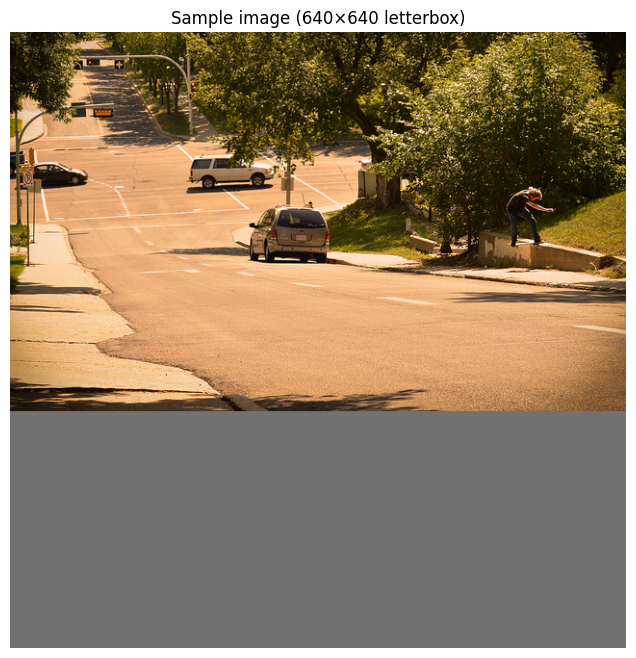

In [46]:
# Quick sanity check: load data and show a sample with masks overlaid.
test_collator = CopyPasteCollator(
    inst_pool=None, max_samples=0, triplet=False,
    train_batch=2, test_batch=0,
    paste_prob=0.0,
)
test_dataset = LVISMaskDataset(train_records, image_size=cfg.IMAGE_SIZE) if 'train_records' in dir() else None
if test_dataset:
    debug_loader = DataLoader(test_dataset, batch_size=2, collate_fn=test_collator)
    images_debug, _ = next(iter(debug_loader))
    img_np = images_debug[0].permute(1, 2, 0).numpy()
    plt.figure(figsize=(8, 8)); plt.imshow(img_np); plt.title("Sample image (640×640 letterbox)"); plt.axis('off');
    plt.show()
else:
    print("[debug] train_records not loaded yet — skip.")

## 21. Baseline Joint Training

In [ ]:
print("[Setup] loading LVIS train records …")
train_records = load_lvis_to_records(
    cfg.TRAIN_ANN_JSON, cfg.TRAIN_IMG_DIR,
    subset_size=cfg.TRAIN_SUBSET_SIZE, seed=cfg.SEED,
)
print("[Setup] loading LVIS val records …")
val_records = load_lvis_to_records(
    cfg.VAL_ANN_JSON, cfg.VAL_IMG_DIR,
    subset_size=cfg.VAL_SUBSET_SIZE, seed=cfg.SEED,
    require_annotations=False,
)

print("[Setup] computing repeat factors …")
repeat_factors = compute_repeat_factors(train_records, cfg.NUM_CLASSES, threshold=0.001)
sampler_train = RepeatFactorSampler(repeat_factors, seed=cfg.SEED)

print("[Setup] building instance pool …")
inst_pool = InstancePool(
    pool_json=cfg.INST_POOL_JSON, root_dir=cfg.INST_POOL_ROOT,
    area_stats_json=cfg.AREA_STATS_JSON,
    scale_min_frac=cfg.SCALE_MIN_FRAC, scale_max_frac=cfg.SCALE_MAX_FRAC,
    mask_threshold=cfg.MASK_THRESHOLD, shape_jitter=cfg.SHAPE_JITTER,
    max_samples=cfg.INST_POOL_MAX_SAMPLES,
)

train_dataset = LVISMaskDataset(train_records, image_size=cfg.IMAGE_SIZE)
val_dataset   = LVISMaskDataset(val_records,   image_size=cfg.IMAGE_SIZE)
eval_loader   = make_eval_loader(val_dataset)

iters_per_epoch = max(1, len(train_records) // cfg.IMS_PER_BATCH)
print(f"[Setup] iters_per_epoch: {iters_per_epoch}")


def run_baseline_training():
    """Stage 1: Joint training of all parameters with federated loss."""
    final_path = os.path.join(cfg.BASELINE_CKPT_DIR, "baseline_final.pth")
    if cfg.SKIP_IF_EXISTS and os.path.exists(final_path):
        print(f"[Baseline] {final_path} exists — skip.")
        return final_path

    total_iters = cfg.BASELINE_ITERS or (cfg.BASELINE_EPOCHS * iters_per_epoch)
    print(f"[Baseline] total_iters = {total_iters}")

    model = build_model(
        num_classes_with_bg=cfg.NUM_CLASSES + 1,
        freq_weight=cat_info["cat_freq_weight"],
        fed_loss_num_cat=cfg.FED_LOSS_NUM_CAT,
        use_fed_loss=cfg.USE_FED_LOSS,
        image_size=cfg.IMAGE_SIZE,
        backbone=cfg.BACKBONE,
        dropout_p=cfg.DROPOUT_P,
    ).to(DEVICE)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=cfg.LR, weight_decay=cfg.WEIGHT_DECAY,
    )
    scaler = torch.amp.GradScaler('cuda') if (cfg.USE_AMP and DEVICE.type == "cuda") else None

    loader = make_baseline_loader(train_dataset, sampler_train, iters_per_epoch)
    data_iter = iter(loader)
    logger = MetricLogger(window=cfg.LOG_EVERY)
    train_log = []

    pbar = tqdm(range(total_iters), desc="[Baseline]")
    t_start = time.time()
    for step in pbar:
        try: batch = next(data_iter)
        except StopIteration:
            data_iter = iter(loader); batch = next(data_iter)

        lr = cosine_warmup_lr(step, cfg.LR, cfg.WARMUP_ITERS, total_iters)
        set_lr(optimizer, lr)
        losses = train_step_baseline(
            model, optimizer, scaler, batch, DEVICE,
            use_amp=cfg.USE_AMP, clip_grad_norm=cfg.CLIP_GRAD_NORM,
        )
        logger.update(**losses, lr=lr)
        if step % cfg.LOG_EVERY == 0:
            pbar.set_postfix_str(logger.fmt(["loss_total", "lr"]))
            train_log.append({"step": step, "loss_total": logger.avg("loss_total"), "lr": lr})
            # ── TensorBoard logging ( objective) ─────────────────
            if writer is not None:
                writer.add_scalar("Baseline/loss_total", logger.avg("loss_total"), step)
                writer.add_scalar("Baseline/lr", lr, step)

        if cfg.CKPT_EVERY_EPOCH > 0 and step > 0 and (step % (iters_per_epoch * cfg.CKPT_EVERY_EPOCH) == 0):
            ck = os.path.join(cfg.BASELINE_CKPT_DIR, f"baseline_iter_{step}.pth")
            torch.save({"model": model.state_dict(), "step": step}, ck)
            print(f"\n[Baseline] → {ck}")

    elapsed = time.time() - t_start
    torch.save({"model": model.state_dict(), "step": total_iters}, final_path)
    with open(os.path.join(cfg.BASELINE_CKPT_DIR, "baseline_training_log.json"), "w") as f:
        json.dump(train_log, f, indent=2)
    print(f"[Baseline] DONE in {elapsed/60:.1f} min → {final_path}")
    return final_path


baseline_ckpt_path = run_baseline_training()

[Setup] loading LVIS train records …
[LVIS] loading /home/fzhnf/Public/study-repos/DiverGen/BSGAL-KELOMPOK-4/datasets/lvis/lvis_v1_train.json ...
[LVIS] 99388 images (0 bad polygons skipped)
[LVIS] subset to 64 records (seed=42)
[Setup] loading LVIS val records …
[LVIS] loading /home/fzhnf/Public/study-repos/DiverGen/BSGAL-KELOMPOK-4/datasets/lvis/lvis_v1_val.json ...
[LVIS] 4809 images (0 bad polygons skipped)
[LVIS] subset to 8 records (seed=42)
[Setup] computing repeat factors …
[Setup] building instance pool …
[InstPool] 1203 cats, avg 87.8 insts/cat
[Setup] iters_per_epoch: 32
[Baseline] /home/fzhnf/Public/study-repos/DiverGen/BSGAL-KELOMPOK-4/models/pretrained-model/baseline_final.pth exists — skip.


## 21b. BSGAL Original  (without classifier-balancing)

Runs BSGAL gradient-based active learning starting from the **baseline**
checkpoint, with all classifier-balancing flags disabled.  This produces
the "BSGAL (original)" column for the three-way comparison.
The result is saved to ``models/bsgal-plain/``.

In [48]:
# BSGAL without any classifier-balancing improvements.
# Same algorithm as the original ICML 2024 paper.
bsgal_plain_ckpt = run_bsgal_training(
    baseline_ckpt_path,
    ckpt_dir=cfg.MODELS_DIR + "/bsgal-plain",
    label="BSGAL-original",
    class_aware=False,
    freeze_backbone=False,
)
print(f"[BSGAL-original] checkpoint: {bsgal_plain_ckpt}")

[BSGAL-original] /home/fzhnf/Public/study-repos/DiverGen/BSGAL-KELOMPOK-4/models/bsgal-plain/bsgal_final.pth exists — skip.
[BSGAL-original] checkpoint: /home/fzhnf/Public/study-repos/DiverGen/BSGAL-KELOMPOK-4/models/bsgal-plain/bsgal_final.pth


## 22. cRT — Classifier Re-Training  *[CB Improvement]*

**Toggle:** ``cfg.USE_CRT``

Loads the baseline checkpoint, freezes the backbone + FPN + RPN, and
retrains only the ROI classifier heads with class-balanced sampling.

This directly addresses the long-tail classifier bias identified by
Kang et al.: the feature representation is already good — only the
classifier weight magnitudes are skewed.

In [49]:
def run_crt_training(baseline_ckpt: str):
    """Stage 2: Classifier Re-Training (cRT) — freeze backbone, retrain classifier."""
    final_path = os.path.join(cfg.CRT_CKPT_DIR, "crt_final.pth")
    if not cfg.USE_CRT:
        print("[CRT] USE_CRT=False — skip.")
        return baseline_ckpt
    if cfg.SKIP_IF_EXISTS and os.path.exists(final_path):
        print(f"[CRT] {final_path} exists — skip.")
        return final_path

    total_iters = cfg.CRT_EPOCHS * iters_per_epoch
    print(f"[CRT] total_iters = {total_iters} (frozen backbone, class-balanced)")

    model = build_model(
        num_classes_with_bg=cfg.NUM_CLASSES + 1,
        freq_weight=cat_info["cat_freq_weight"],
        fed_loss_num_cat=cfg.FED_LOSS_NUM_CAT,
        use_fed_loss=cfg.USE_FED_LOSS,
        image_size=cfg.IMAGE_SIZE,
        freeze_backbone=True,
        backbone=cfg.BACKBONE,
        dropout_p=cfg.DROPOUT_P,
    ).to(DEVICE)

    state = torch.load(baseline_ckpt, map_location=DEVICE)
    model.load_state_dict(state["model"], strict=False)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=cfg.CRT_LR, weight_decay=cfg.WEIGHT_DECAY,
    )
    scaler = torch.amp.GradScaler('cuda') if (cfg.USE_AMP and DEVICE.type == "cuda") else None

    loader = make_baseline_loader(train_dataset, sampler_train, iters_per_epoch)
    data_iter = iter(loader)
    logger = MetricLogger(window=cfg.LOG_EVERY)

    pbar = tqdm(range(total_iters), desc="[CRT]")
    for step in pbar:
        try: batch = next(data_iter)
        except StopIteration:
            data_iter = iter(loader); batch = next(data_iter)

        lr = cosine_warmup_lr(step, cfg.CRT_LR, cfg.WARMUP_ITERS // 4, total_iters)
        set_lr(optimizer, lr)
        losses = train_step_baseline(
            model, optimizer, scaler, batch, DEVICE,
            use_amp=cfg.USE_AMP, clip_grad_norm=cfg.CLIP_GRAD_NORM,
        )
        logger.update(**losses, lr=lr)
        if step % cfg.LOG_EVERY == 0:
            pbar.set_postfix_str(logger.fmt(["loss_total", "lr"]))
            if writer is not None:
                writer.add_scalar("cRT/loss_total", logger.avg("loss_total"), step)
                writer.add_scalar("cRT/lr", lr, step)

    torch.save({"model": model.state_dict(), "step": total_iters}, final_path)
    print(f"[CRT] DONE → {final_path}")
    return final_path


crt_ckpt = run_crt_training(baseline_ckpt_path)
ckpt_current = crt_ckpt  # chain forward

[CRT] USE_CRT=False — skip.


## 23. LWS — Learnable Weight Scaling Training  *[CB Improvement]*

**Toggle:** ``cfg.USE_LWS``

Loads the cRT (or baseline) checkpoint, replaces the classifier ``cls_score``
with an ``LWSClassifier``, and trains only the per-class ``scales``
vector (1,203 parameters) with class-balanced sampling.

In [50]:
def run_lws_training(input_ckpt: str):
    """Stage 3: LWS — freeze weights, train per-class scales (1,203 params)."""
    final_path = os.path.join(cfg.LWS_CKPT_DIR, "lws_final.pth")
    if not cfg.USE_LWS:
        print("[LWS] USE_LWS=False — skip.")
        return input_ckpt
    if cfg.SKIP_IF_EXISTS and os.path.exists(final_path):
        print(f"[LWS] {final_path} exists — skip.")
        return final_path

    total_iters = cfg.LWS_EPOCHS * iters_per_epoch
    print(f"[LWS] total_iters = {total_iters}")

    model = build_model(
        num_classes_with_bg=cfg.NUM_CLASSES + 1,
        freq_weight=cat_info["cat_freq_weight"],
        fed_loss_num_cat=cfg.FED_LOSS_NUM_CAT,
        use_fed_loss=cfg.USE_FED_LOSS,
        image_size=cfg.IMAGE_SIZE,
        freeze_backbone=True,
        backbone=cfg.BACKBONE,
        dropout_p=0.0,  # LWS trains only scales; dropout not needed
    ).to(DEVICE)

    state = torch.load(input_ckpt, map_location=DEVICE)
    model.load_state_dict(state["model"], strict=False)
    replace_with_lws_classifier(model)

    trainable = [p for p in model.parameters() if p.requires_grad]
    print(f"[LWS] Trainable: {sum(p.numel() for p in trainable)} params")
    optimizer = torch.optim.AdamW(trainable, lr=cfg.CRT_LR, weight_decay=0.0)

    loader = make_baseline_loader(train_dataset, sampler_train, iters_per_epoch)
    data_iter = iter(loader)
    logger = MetricLogger(window=cfg.LOG_EVERY)

    pbar = tqdm(range(total_iters), desc="[LWS]")
    for step in pbar:
        try: batch = next(data_iter)
        except StopIteration:
            data_iter = iter(loader); batch = next(data_iter)

        lr = cosine_warmup_lr(step, cfg.CRT_LR, 10, total_iters)
        set_lr(optimizer, lr)
        losses = train_step_baseline(
            model, optimizer, None, batch, DEVICE,
            use_amp=False, clip_grad_norm=cfg.CLIP_GRAD_NORM,
        )
        logger.update(**losses, lr=lr)
        if step % cfg.LOG_EVERY == 0:
            pbar.set_postfix_str(logger.fmt(["loss_total", "lr"]))
            if writer is not None:
                writer.add_scalar("LWS/loss_total", logger.avg("loss_total"), step)
                writer.add_scalar("LWS/lr", lr, step)

    torch.save({"model": model.state_dict(), "step": total_iters}, final_path)
    print(f"[LWS] DONE → {final_path}")
    return final_path


lws_ckpt = run_lws_training(ckpt_current)
ckpt_current = lws_ckpt

[LWS] USE_LWS=False — skip.


## 24. BSGAL Active Learning  (with optional CB improvements)

**Toggle:** ``cfg.BSGAL_ENABLED``

The BSGAL active-learning phase can run with the following enhancements:

- ``FREEZE_BACKBONE_BSGAL`` — classifier-only gradients (1.2M dim)
- ``USE_CLASS_AWARE`` — rarity-weighted per-class gradient similarity

Both can be combined for the strongest class-aware signal.

In [51]:
# BSGAL+CB — run the BSGAL active-learning stage starting from the
# classifier-balancing checkpoint chain (cRT → LWS).
# All CB flags are active: class_aware, freeze_backbone, etc.
bsgal_cb_ckpt = run_bsgal_training(
    ckpt_current,
    ckpt_dir=cfg.BSGAL_CKPT_DIR,
    label="BSGAL+CB",
)
bsgal_ckpt_path = bsgal_cb_ckpt  # backward-compat name

[BSGAL+CB] /home/fzhnf/Public/study-repos/DiverGen/BSGAL-KELOMPOK-4/models/model/bsgal_final.pth exists — skip.


## 25. Final Evaluation & Three-Way Comparison

Loads all checkpoints (Baseline, BSGAL-original, BSGAL+CB),
optionally applies τ-normalization, and prints a three-way comparison
table of LVIS AP **and F1 scores**.

**Key metrics for long-tailed evaluation:**

- **APr / F1_rare**   — performance on rare classes (< 10 training images)
- **APc / F1_common** — performance on common classes (10–100 images)
- **APf / F1_freq**   — performance on frequent classes (> 100 images)

F1-score is reported per the  requirement (macro-average across
all 1,203 classes, plus stratified by class frequency).


Evaluating Baseline …
[Baseline] running evaluation …


[06/05 13:53:36] lvis.results WARNING: Assuming user provided the results in correct format.
[06/05 13:57:13] lvis.results WARNING: Assuming user provided the results in correct format.


Evaluating BSGAL (original, no CB) …
[BSGAL-orig] running evaluation …


[06/05 14:00:48] lvis.results WARNING: Assuming user provided the results in correct format.
[06/05 14:04:25] lvis.results WARNING: Assuming user provided the results in correct format.


Evaluating BSGAL (final pipeline) …
[BSGAL+CB] running evaluation …


[06/05 14:07:38] lvis.results WARNING: Assuming user provided the results in correct format.
[06/05 14:10:54] lvis.results WARNING: Assuming user provided the results in correct format.



Metric           Baseline        BSGAL     BSGAL+CB    Δ(orig)     Δ(+CB)
-------------------------------------------------------------------------------------
AP                  0.000        0.000        0.000     +0.000     +0.000
AP50                0.000        0.000        0.000     +0.000     +0.000
AP75                0.000        0.000        0.000     +0.000     +0.000
APs                 0.000        0.000        0.000     +0.000     +0.000
APm                 0.000        0.000        0.000     +0.000     +0.000
APl                 0.000        0.000        0.000     +0.000     +0.000
APr                 0.000        0.000        0.000     +0.000     +0.000
APc                 0.000        0.000        0.000     +0.000     +0.000
APf                 0.000        0.000        0.000     +0.000     +0.000
F1_macro            0.000        0.000        0.000     +0.000     +0.000
F1_rare             0.000        0.000        0.000     +0.000     +0.000
F1_common           0.000

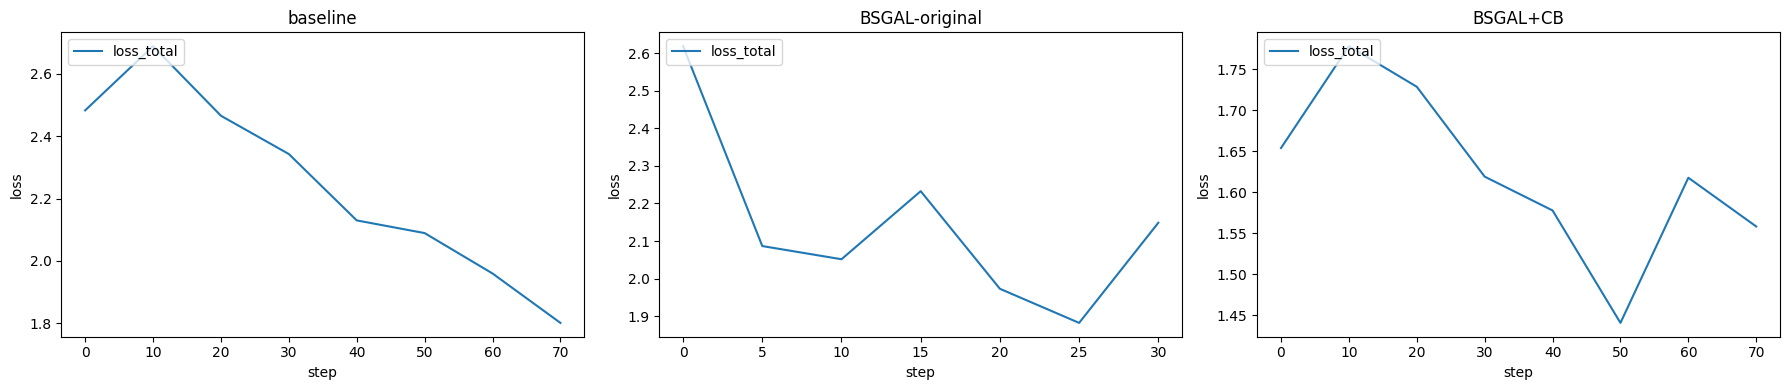

[Model] Dropout(p=0.2) added before cls_score
[vis] Loaded Baseline from baseline_final.pth
[Model] Dropout(p=0.2) added before cls_score
[vis] Loaded BSGAL-orig from bsgal_final.pth
[Model] Dropout(p=0.2) added before cls_score
[vis] Loaded BSGAL+CB from bsgal_final.pth


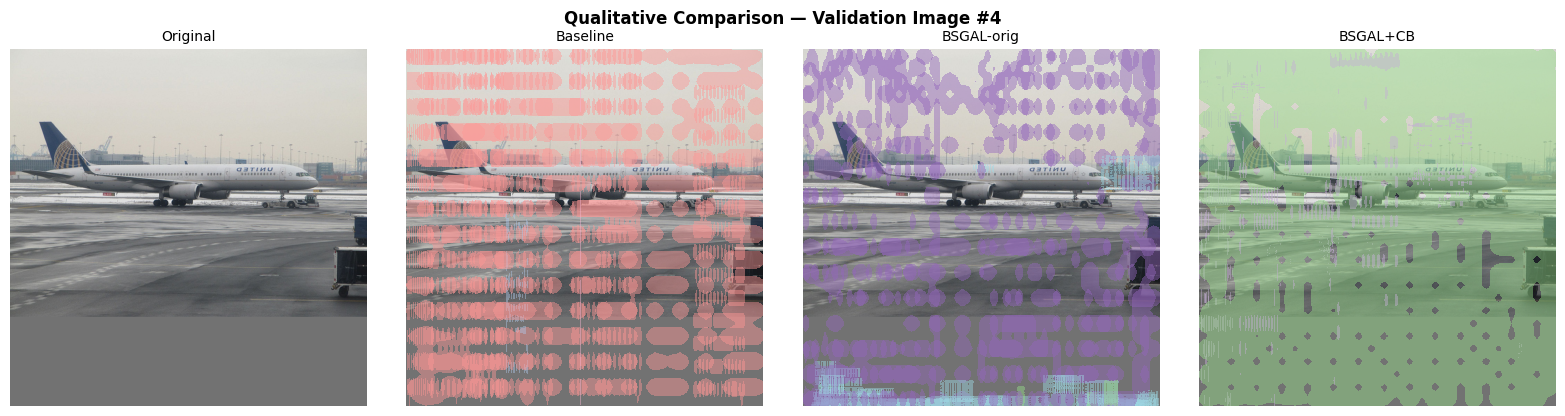

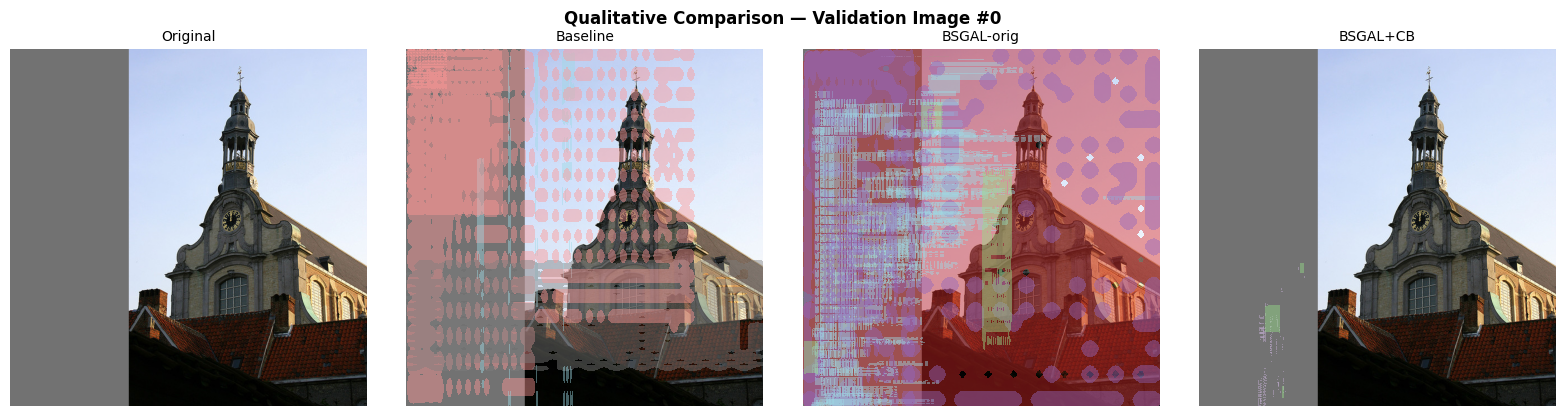

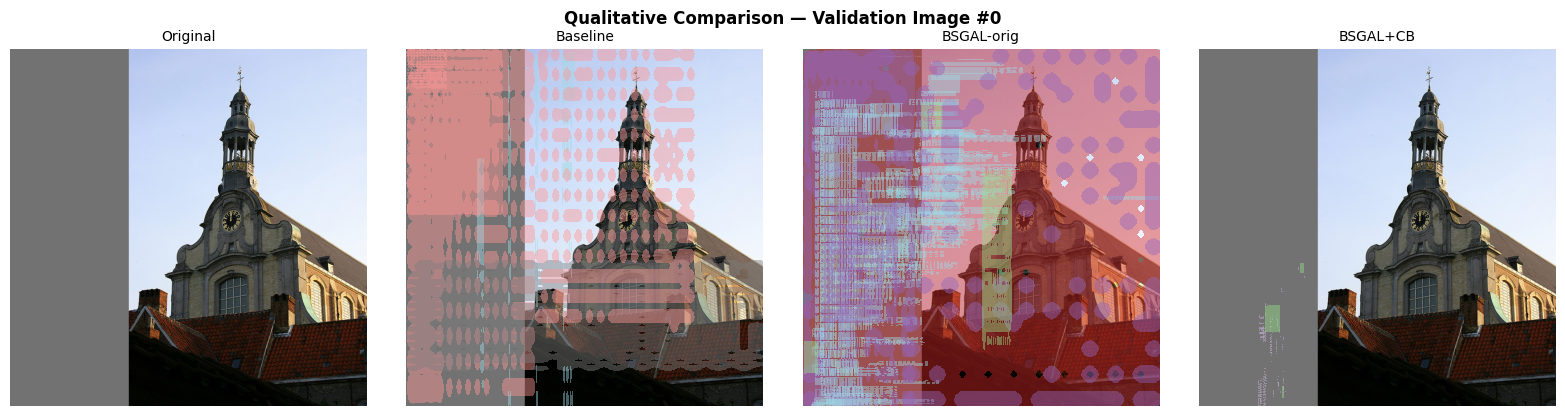


[TensorBoard] writer closed — launch with:
  tensorboard --logdir /home/fzhnf/Public/study-repos/DiverGen/BSGAL-KELOMPOK-4/runs/bsgal_2026-06-05_14-14-38

Pipeline complete.


In [ ]:
# ── τ-normalization grid search (if enabled) ────────────────────────────────
tau_p = cfg.TAUDEVICE, apply_tau_norm=use_tau, tau_p=tau_p,
                                       compute_f1=True)

# BSGAL original (no CB) — from the standalone BSGAL-plain training stage
metrics_bsgal_plain = {}
if 'bsgal_plain_ckpt' in dir() and bsgal_plain_ckpt and os.path.exists(bsgal_plain_ckpt):
    print("Evaluating BSGAL (original, no CB) …")
    metrics_bsgal_plain = evaluate_checkpoint(bsgal_plain_ckpt, eval_loader,
                                              "BSGAL-orig", DEVICE,
                                              apply_tau_norm=use_tau, tau_p=tau_p,
                                         S     compute_f1=True)

# BSGAL+CB (full pipeline: cRT → LWS → BSGAL with CB flags)
metrics_bsgal_cb = {}
if bsgal_ckpt_path and os.path.exists(bsgal_ckpt_path):
    print("Evaluating BSGAL (final pipeline) …")
    metrics_bsgal_cb = evaluate_checkpoint(bsgal_ckpt_path, eval_loader, "BSGAL+CB",
                                        DEVICE, apply_tau_norm=use_tau, tau_p=tau_p,
                                        compute_f1=True)

# The BSGAL training stage already consumed all previous stages (cRT→LWS→BSGAL).
# When any CB flag is active, the BSGAL result IS BSGAL+CB.
# The "BSGAL" column shows the original pipeline; "BSGAL+CB" = final result.

# ── Results table: AP + F1 metrics ──────────────────────────────────────────
ap_keys   = ["AP", "AP50", "AP75", "APs", "APm", "APl", "APr", "APc", "APf"]
f1_keys   = ["F1_macro", "F1_rare", "F1_common", "F1_freq"]
all_keys  = ap_keys + f1_keys

print("\n" + "=" * 85)
print(f"{'Metric':<12} {'Baseline':>12} {'BSGAL':>12} {'BSGAL+CB':>12} {'Δ(orig)':>10} {'Δ(+CB)':>10}")
print("-" * 85)
for k in all_keys:
    b  = metrics_baseline.get(k, 0.0)
    g  = metrics_bsgal_plain.get(k, 0.0) if metrics_bsgal_plain else 0.0
    cb = metrics_bsgal_cb.get(k, 0.0) if metrics_bsgal_cb else 0.0
    d_orig = g - b
    d_cb   = cb - b
    print(f"{k:<12} {b:>12.3f} {g:>12.3f} {cb:>12.3f} {d_orig:>+10.3f} {d_cb:>+10.3f}")
print("=" * 85)
if cfg.USE_TAU_NORM:
    print(f"\nτ-normalization applied with best p = {tau_p:.2f}")

# ── Highlight F1 improvements ( objective) ────────────────────────────
if metrics_bsgal_cb:
    print("\n--- F1-Score Summary () ---")
    for k in f1_keys:
        b = metrics_baseline.get(k, 0.0)
        g = metrics_bsgal_cb.get(k, 0.0)
        print(f"  {k:<14}  Baseline={b:.4f}  BSGAL={g:.4f}  Δ={g-b:+.4f}")

# ── Active CB improvements summary ─────────────────────────────────────────
cb_improvements = []
if cfg.USE_CRT:        cb_improvements.append("cRT")
if cfg.USE_TAU_NORM:   cb_improvements.append(f"τ-norm(p={tau_p:.2f})")
if cfg.USE_LWS:        cb_improvements.append("LWS")
if cfg.USE_CLASS_AWARE: cb_improvements.append("Class-Aware BSGAL")
if cfg.FREEZE_BACKBONE_BSGAL: cb_improvements.append("Frozen-BB BSGAL")
if cfg.DROPOUT_P > 0:  cb_improvements.append(f"Dropout(p={cfg.DROPOUT_P})")
if cb_improvements:
    print(f"\nActive improvements: {', '.join(cb_improvements)}")

# ── Loss / similarity plot ──────────────────────────────────────────────────
log_paths = []
bp = os.path.join(cfg.BASELINE_CKPT_DIR, "baseline_training_log.json")
gp = os.path.join(cfg.MODELS_DIR + "/bsgal-plain", "training_log.json")
cp = os.path.join(cfg.BSGAL_CKPT_DIR, "training_log.json")
if os.path.exists(bp): log_paths.append(("baseline", bp))
if os.path.exists(gp): log_paths.append(("BSGAL-original", gp))
if os.path.exists(cp): log_paths.append(("BSGAL+CB", cp))

if log_paths:
    fig, axes = plt.subplots(1, len(log_paths), figsize=(6 * len(log_paths), 4), squeeze=False)
    for ax, (name, path) in zip(axes[0], log_paths):
        with open(path) as f:
            log = json.load(f)
        steps = [e["step"] for e in log]
        loss = [e.get("loss_total", 0.0) for e in log]
        ax.plot(steps, loss, label="loss_total")
        if name == "bsgal":
            sp = [e.get("sim_paste", 0.0) for e in log]
            so = [e.get("sim_ori", 0.0) for e in log]
            ax2 = ax.twinx()
            ax2.plot(steps, sp, color="tab:orange", alpha=0.6, label="sim_paste")
            ax2.plot(steps, so, color="tab:green", alpha=0.6, label="sim_ori")
            ax2.set_ylabel("cosine sim")
            ax2.legend(loc="upper right")
        ax.set_title(name)
        ax.set_xlabel("step"); ax.set_ylabel("loss")
        ax.legend(loc="upper left")
    plt.tight_layout(); plt.show()

# ── Close TensorBoard writer ( objective) ─────────────────────────────

# ── Qualitative Comparison: side-by-side segmentation ────────────────────
all_ckpts = [
    ("Baseline",     baseline_ckpt_path),
    ("BSGAL-orig",   bsgal_plain_ckpt  if 'bsgal_plain_ckpt' in dir() else None),
    ("BSGAL+CB",     bsgal_ckpt_path),
]
valid_ckpts = [(n, p) for n, p in all_ckpts if p and os.path.exists(p)]
if len(valid_ckpts) >= 2:
    from torchvision.transforms.functional import normalize as tv_norm

    models_vis = {}
    for name, ckpt in valid_ckpts:
        n_cls = cfg.NUM_CLASSES + 1
        model = build_model(
            n_cls, cat_info["cat_freq_weight"],
            cfg.FED_LOSS_NUM_CAT, cfg.USE_FED_LOSS,
            image_size=cfg.IMAGE_SIZE,
            backbone=cfg.BACKBONE, dropout_p=cfg.DROPOUT_P,
        ).to(DEVICE)
        model.eval()
        ck = torch.load(ckpt, map_location="cpu")
        model.load_state_dict(ck["model"], strict=False)  # robust to ckpt format drift
        models_vis[name] = model
        print(f"[vis] Loaded {name} from {os.path.basename(ckpt)}")

    # Pick a few test images from the validation dataset
    num_show = min(3, len(val_dataset))
    idxs = torch.randint(0, len(val_dataset), (num_show,)).tolist()

    colours = plt.cm.tab20(np.linspace(0, 1, 20))

    for img_idx in idxs:
        item = val_dataset[img_idx]
        # Raw uint8 image for display
        img_uint8 = item.get("image_rgb_uint8")
        if img_uint8 is None:
            print(f"[vis] img {img_idx}: no 'image_rgb_uint8' key; skipping")
            continue

        # Prepare normalised tensor for inference
        img_t = torch.from_numpy(img_uint8).float().permute(2, 0, 1) / 255.0  # [3,H,W]
        img_t = tv_norm(img_t, [0.485, 0.456, 0.406], [0.229, 0.224, 0.225])

        n_cols = 1 + len(models_vis)
        fig, axes = plt.subplots(1, n_cols, figsize=(4 * n_cols, 4.2))
        axes[0].imshow(img_uint8)
        axes[0].set_title("Original", fontsize=10)
        axes[0].axis("off")

        for col, (name, model) in enumerate(models_vis.items(), start=1):
            with torch.no_grad():
                out = model([img_t.to(DEVICE)])[0]
            masks  = out["masks"].cpu().numpy()        # [N,1,H,W]
            scores = out["scores"].cpu().numpy()        # [N]
            labels = out["labels"].cpu().numpy()        # [N]
            keep = scores >= 0.3
            masks, labels = masks[keep], labels[keep]

            ax = axes[col]
            ax.imshow(img_uint8)
            for i in range(len(masks)):
                m = masks[i][0] > 0.3
                if m.any():
                    cid = int(labels[i]) - 1  # LVIS 1-indexed → our 0-indexed
                    colour = colours[cid % len(colours)]
                    ax.imshow(
                        np.ma.masked_where(~m, np.ones_like(m)),
                        cmap=plt.cm.colors.ListedColormap([colour]),
                        alpha=0.45, interpolation="nearest",
                    )
            ax.set_title(name, fontsize=10)
            ax.axis("off")
        plt.suptitle(f"Qualitative Comparison — Validation Image #{img_idx}",
                     fontsize=12, fontweight="bold")
        plt.tight_layout()
        plt.show()

    # Clean up
    for m in models_vis.values():
        del m
    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()
else:
    print("⚠️  Skipping visual comparison — fewer than 2 checkpoints found.")

# ── Close TensorBoard writer ( objective) ─────────────────────────────
if writer is not None:
    writer.close()
    print(f"\n[TensorBoard] writer closed — launch with:")
    print(f"  tensorboard --logdir {cfg.TENSORBOARD_DIR}")

print("\nPipeline complete.")